<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Preset_and_non_preset_30526.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sheets = pd.ExcelFile('/content/drive/MyDrive/Preset and non-preset original data.xlsx')
sheets.sheet_names

['preop preset',
 'postop preset1wk',
 'preop nonpreset',
 'postop nonpreset1wk',
 'postop1wk both',
 'unified preop preset',
 'unified postop preset',
 'unified preop nonpreset',
 'unified postop nonpreset',
 'preoppreset',
 'postoppreset',
 'preopnonpreset',
 'postopnonpreset']

In [3]:
preop_preset = sheets.parse('preoppreset')
preop_nonpreset = sheets.parse('preopnonpreset')
postop_preset = sheets.parse('postoppreset')
postop_nonpreset = sheets.parse('postopnonpreset')

In [4]:
preop_preset['M'] = (preop_preset['R2'] - preop_preset['R1'])/2
preop_nonpreset['M'] = (preop_nonpreset['R2'] - preop_nonpreset['R1'])/2
postop_preset['M'] = (postop_preset['R2'] - postop_preset['R1'])/2
postop_nonpreset['M'] = (postop_nonpreset['R2'] - postop_nonpreset['R1'])/2


In [5]:
preop_preset['cylinder'] = (preop_preset['R2'] - preop_preset['R1'])
preop_nonpreset['cylinder'] = (preop_nonpreset['R2'] - preop_nonpreset['R1'])
postop_preset['cylinder'] = (postop_preset['R2'] - postop_preset['R1'])
postop_nonpreset['cylinder'] = (postop_nonpreset['R2'] - postop_nonpreset['R1'])


In [6]:
preop_preset['steepaxis'] = (preop_preset['A1'] + 90) % 180
preop_nonpreset['steepaxis'] = (preop_nonpreset['A1']+90) % 180
postop_preset['steepaxis'] = (postop_nonpreset['A1']+90) % 180
postop_nonpreset['steepaxis'] = (postop_nonpreset['A1']+90) % 180


In [7]:
preop_preset['alpha'] = np.deg2rad(preop_preset['steepaxis'])
preop_nonpreset['alpha'] = np.deg2rad(preop_nonpreset['steepaxis'])
postop_preset['alpha'] = np.deg2rad(postop_preset['steepaxis'])
postop_nonpreset['alpha'] = np.deg2rad(postop_nonpreset['steepaxis'])


In [8]:
preop_preset.shape, preop_nonpreset.shape, postop_preset.shape, postop_nonpreset.shape

((42, 11), (26, 11), (42, 11), (26, 11))

### Age shapiro test

In [9]:
preop_preset['Age'].describe(), preop_nonpreset['Age'].describe()

(count    42.000000
 mean     66.761905
 std       9.312487
 min      39.000000
 25%      60.000000
 50%      65.000000
 75%      75.500000
 max      82.000000
 Name: Age, dtype: float64,
 count    26.000000
 mean     66.615385
 std       8.197936
 min      44.000000
 25%      63.250000
 50%      67.000000
 75%      72.000000
 max      81.000000
 Name: Age, dtype: float64)

In [10]:
preop_preset['M'].describe(), preop_nonpreset['M'].describe()

(count    42.000000
 mean      0.431548
 std       0.280465
 min      -0.250000
 25%       0.250000
 50%       0.375000
 75%       0.625000
 max       1.125000
 Name: M, dtype: float64,
 count    26.000000
 mean      0.461538
 std       0.309777
 min       0.000000
 25%       0.250000
 50%       0.375000
 75%       0.500000
 max       1.375000
 Name: M, dtype: float64)

In [11]:
postop_preset['M'].describe(), postop_nonpreset['M'].describe()

(count    42.000000
 mean      1.041774
 std       0.877540
 min       0.000000
 25%       0.375000
 50%       0.812500
 75%       1.375000
 max       3.379500
 Name: M, dtype: float64,
 count    26.000000
 mean      0.725962
 std       0.608296
 min      -1.125000
 25%       0.500000
 50%       0.750000
 75%       1.093750
 max       1.750000
 Name: M, dtype: float64)

In [12]:
preop_preset['cylinder'].describe(), preop_nonpreset['cylinder'].describe()

(count    42.000000
 mean      0.863095
 std       0.560929
 min      -0.500000
 25%       0.500000
 50%       0.750000
 75%       1.250000
 max       2.250000
 Name: cylinder, dtype: float64,
 count    26.000000
 mean      0.923077
 std       0.619553
 min       0.000000
 25%       0.500000
 50%       0.750000
 75%       1.000000
 max       2.750000
 Name: cylinder, dtype: float64)

### shapiro for M

In [13]:
from scipy.stats import shapiro

# Preset group
stat_preset, p_preset = shapiro(preop_preset['M'].dropna())

print("Preset Group - M")
print("Shapiro statistic =", round(stat_preset,4))
print("p value =", round(p_preset,4))

# Non-preset group
stat_nonpreset, p_nonpreset = shapiro(preop_nonpreset['M'].dropna())

print("\nNon-preset Group - M")
print("Shapiro statistic =", round(stat_nonpreset,4))
print("p value =", round(p_nonpreset,4))

Preset Group - M
Shapiro statistic = 0.9615
p value = 0.167

Non-preset Group - M
Shapiro statistic = 0.8555
p value = 0.0018


In [14]:
from scipy.stats import shapiro

# Preset group
stat_preset, p_preset = shapiro(preop_preset['cylinder'].dropna())

print("Preset Group - cylinder")
print("Shapiro statistic =", round(stat_preset,4))
print("p value =", round(p_preset,4))

# Non-preset group
stat_nonpreset, p_nonpreset = shapiro(preop_nonpreset['cylinder'].dropna())

print("\nNon-preset Group - cylinder")
print("Shapiro statistic =", round(stat_nonpreset,4))
print("p value =", round(p_nonpreset,4))

Preset Group - cylinder
Shapiro statistic = 0.9615
p value = 0.167

Non-preset Group - cylinder
Shapiro statistic = 0.8555
p value = 0.0018


### preop m and cylinder median IQR

In [15]:
for var in ['M', 'cylinder']:
    print(f"\n{var}")

    for name, df in [('Preset', preop_preset), ('Non-preset', preop_nonpreset)]:

        med = df[var].median()
        q1 = df[var].quantile(0.25)
        q3 = df[var].quantile(0.75)

        print(f"{name}: {med:.2f} ({q1:.2f}–{q3:.2f})")


M
Preset: 0.38 (0.25–0.62)
Non-preset: 0.38 (0.25–0.50)

cylinder
Preset: 0.75 (0.50–1.25)
Non-preset: 0.75 (0.50–1.00)


###

### postop m and cylinder median IQR

In [16]:
for var in ['M', 'cylinder']:
    print(f"\n{var}")

    for name, df in [('Preset', postop_preset), ('Non-preset', postop_nonpreset)]:

        med = df[var].median()
        q1 = df[var].quantile(0.25)
        q3 = df[var].quantile(0.75)

        print(f"{name}: {med:.2f} ({q1:.2f}–{q3:.2f})")


M
Preset: 0.81 (0.38–1.38)
Non-preset: 0.75 (0.50–1.09)

cylinder
Preset: 1.62 (0.75–2.75)
Non-preset: 1.50 (1.00–2.19)


### preop mannwhitney

In [17]:
from scipy.stats import mannwhitneyu

variables = ['M', 'cylinder']

for var in variables:

    stat, p = mannwhitneyu(
        preop_preset[var].dropna(),
        preop_nonpreset[var].dropna(),
        alternative='two-sided'
    )

    print(f"\n--- {var} ---")
    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Mann–Whitney U statistic = 537.000
p value = 0.9135

--- cylinder ---
Mann–Whitney U statistic = 537.000
p value = 0.9135


### post op mannwhitney

In [18]:
from scipy.stats import mannwhitneyu

variables = ['M', 'cylinder']

for var in variables:

    stat, p = mannwhitneyu(
        postop_preset[var].dropna(),
        postop_nonpreset[var].dropna(),
        alternative='two-sided'
    )

    print(f"\n--- {var} ---")
    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Mann–Whitney U statistic = 596.000
p value = 0.5311

--- cylinder ---
Mann–Whitney U statistic = 596.000
p value = 0.5311


In [19]:
print(preop_preset[['M','cylinder']].corr())
print(preop_nonpreset[['M','cylinder']].corr())

            M  cylinder
M         1.0       1.0
cylinder  1.0       1.0
            M  cylinder
M         1.0       1.0
cylinder  1.0       1.0


### mannwhitney within grps

In [20]:
from scipy.stats import mannwhitneyu

variables = ['M', 'cylinder']

for var in variables:

    stat, p = mannwhitneyu(
        preop_preset[var].dropna(),
        postop_preset[var].dropna(),
        alternative='two-sided'
    )

    print(f"\n--- {var} ---")
    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Mann–Whitney U statistic = 508.000
p value = 0.0008

--- cylinder ---
Mann–Whitney U statistic = 508.000
p value = 0.0008


In [21]:
from scipy.stats import wilcoxon

variables = ['M', 'cylinder']

for var in variables:

    stat, p = wilcoxon(
        preop_preset[var].dropna(),
        postop_preset[var].dropna()
    )

    print(f"\n--- {var} ---")
    print(f"Wilcoxon statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Wilcoxon statistic = 114.000
p value = 0.0003

--- cylinder ---
Wilcoxon statistic = 114.000
p value = 0.0003


In [22]:
from scipy.stats import wilcoxon

variables = ['M', 'cylinder']

for var in variables:

    stat, p = wilcoxon(
        preop_nonpreset[var].dropna(),
        postop_nonpreset[var].dropna()
    )

    print(f"\n--- {var} ---")
    print(f"Wilcoxon statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Wilcoxon statistic = 53.500
p value = 0.0175

--- cylinder ---
Wilcoxon statistic = 53.500
p value = 0.0175


In [23]:
from scipy.stats import mannwhitneyu

variables = ['M', 'cylinder']

for var in variables:

    stat, p = mannwhitneyu(
        preop_nonpreset[var].dropna(),
        postop_nonpreset[var].dropna(),
        alternative='two-sided'
    )

    print(f"\n--- {var} ---")
    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Mann–Whitney U statistic = 187.500
p value = 0.0057

--- cylinder ---
Mann–Whitney U statistic = 187.500
p value = 0.0057


### for Preset vs Non-preset (independent groups), use Mann–Whitney U test.

Code for between-group comparison of M and cylinder:

In [24]:
from scipy.stats import mannwhitneyu

for var in ['M', 'cylinder']:

    stat, p = mannwhitneyu(
        preop_preset[var].dropna(),
        preop_nonpreset[var].dropna(),
        alternative='two-sided'
    )

    print(f"\n--- {var} ---")
    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Mann–Whitney U statistic = 537.000
p value = 0.9135

--- cylinder ---
Mann–Whitney U statistic = 537.000
p value = 0.9135


In [25]:
from scipy.stats import mannwhitneyu

for var in ['M', 'cylinder']:

    stat, p = mannwhitneyu(
        postop_preset[var].dropna(),
        postop_nonpreset[var].dropna(),
        alternative='two-sided'
    )

    print(f"\n--- {var} ---")
    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4f}")


--- M ---
Mann–Whitney U statistic = 596.000
p value = 0.5311

--- cylinder ---
Mann–Whitney U statistic = 596.000
p value = 0.5311


In [26]:
import pandas as pd

summary = pd.DataFrame({
    'Preset': preop_preset['Age'].describe(),
    'Non-Preset': preop_nonpreset['Age'].describe()
})

summary.loc['skew'] = [
    preop_preset['Age'].skew(),
    preop_nonpreset['Age'].skew()
]

summary.loc['kurtosis'] = [
    preop_preset['Age'].kurt(),
    preop_nonpreset['Age'].kurt()
]

print(summary)

             Preset  Non-Preset
count     42.000000   26.000000
mean      66.761905   66.615385
std        9.312487    8.197936
min       39.000000   44.000000
25%       60.000000   63.250000
50%       65.000000   67.000000
75%       75.500000   72.000000
max       82.000000   81.000000
skew      -0.318178   -0.863273
kurtosis   0.401289    1.437613


In [27]:
from scipy.stats import shapiro

# Preset group
stat_preset, p_preset = shapiro(preop_preset['Age'])
print("Preset group:")
print("Statistic =", stat_preset)
print("p-value   =", p_preset)

# Non-preset group
stat_nonpreset, p_nonpreset = shapiro(preop_nonpreset['Age'])
print("\nNon-preset group:")
print("Statistic =", stat_nonpreset)
print("p-value   =", p_nonpreset)

Preset group:
Statistic = 0.9470619781074014
p-value   = 0.050721251907817934

Non-preset group:
Statistic = 0.9511174557260949
p-value   = 0.24626409851936798


In [28]:
from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(
    preop_preset['Age'],
    preop_nonpreset['Age'],
    alternative='two-sided'
)

print(f"U = {u_stat:.3f}, p = {p_val:.4f}")

if p_val < 0.05:
    print("Result: Significant difference between groups")
else:
    print("Result: No significant difference between groups")

U = 527.000, p = 0.8152
Result: No significant difference between groups


In [29]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    preop_preset['Age'],
    preop_nonpreset['Age'],
    equal_var=False  # Welch’s t-test
)

print(f"t = {t_stat:.4f}, p = {p_val:.4f}")

t = 0.0679, p = 0.9461


In [30]:
from scipy.stats import shapiro

# Shapiro test for age in preop_preset
stat1, p1 = shapiro(preop_preset['Age'])

# Shapiro test for age in preop_nonpreset
stat2, p2 = shapiro(preop_nonpreset['Age'])

print("Preop Preset - Statistic:", stat1, "p-value:", p1)
print("Preop Nonpreset - Statistic:", stat2, "p-value:", p2)

Preop Preset - Statistic: 0.9470619781074014 p-value: 0.050721251907817934
Preop Nonpreset - Statistic: 0.9511174557260949 p-value: 0.24626409851936798


In [31]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(preop_preset['Age'], preop_nonpreset['Age'])

print("t-statistic:", stat)
print("p-value:", p)

t-statistic: 0.06592281964587492
p-value: 0.9476385556673202


In [32]:
import numpy as np
from scipy.stats import chi2_contingency

# Rows: Gender (Female, Male)
# Columns: Groups (Preset, Non-preset)
table = np.array([
    [27, 14],  # Females
    [15, 12]   # Males
])

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square = {chi2:.4f}")
print(f"p-value    = {p:.4f}")
print(f"Degrees of freedom = {dof}")
print("Expected frequencies:\n", expected)

Chi-square = 0.3600
p-value    = 0.5485
Degrees of freedom = 1
Expected frequencies:
 [[25.32352941 15.67647059]
 [16.67647059 10.32352941]]


In [33]:
preop_preset['J0'] = -(preop_preset['cylinder']/2) * np.cos(2 * preop_preset['alpha'])

preop_preset['J45'] = -(preop_preset['cylinder']/2) * np.sin(2 * preop_preset['alpha'])
preop_preset.head()

,Name,Age,Gender,Operating eye,R1,R2,A1,M,cylinder,steepaxis,alpha,J0,J45
0,Deviramma,55,F,RE,43.50,43.75,35,0.125,0.25,125,2.181662,0.042753,0.117462
1,Sakamma,69,F,RE,43.00,44.00,75,0.500,1.00,165,2.879793,-0.433013,0.250000
2,Malamma,64,F,LE,44.50,46.00,95,0.750,1.50,5,0.087266,-0.738606,-0.130236
3,Rajkumar,57,M,RE,43.25,44.50,60,0.625,1.25,150,2.617994,-0.312500,0.541266
4,Chanappa,79,M,RE,42.25,43.75,100,0.750,1.50,10,0.174533,-0.704769,-0.256515


### Cohens d effect size for Age

In [34]:
import numpy as np

x = preop_preset['Age']
y = preop_nonpreset['Age']

nx, ny = len(x), len(y)

mean_x, mean_y = np.mean(x), np.mean(y)
sd_x, sd_y = np.std(x, ddof=1), np.std(y, ddof=1)

# pooled standard deviation
pooled_sd = np.sqrt(((nx - 1)*sd_x**2 + (ny - 1)*sd_y**2) / (nx + ny - 2))

cohens_d = (mean_x - mean_y) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: 0.016450492778067705


### Astigmatism type in preop preset group

In [35]:
def classify_astigmatism(J0, J45, threshold=0.75):
    if abs(J45) >= threshold:
        return "Oblique"
    elif J0 > 0:
        return "WTR"
    else:
        return "ATR"

preop_preset["Astigmatism_Type"] = preop_preset.apply(
    lambda row: classify_astigmatism(row["J0"], row["J45"]), axis=1
)

# Count
counts = preop_preset["Astigmatism_Type"].value_counts()

# Percentage
percentages = preop_preset["Astigmatism_Type"].value_counts(normalize=True) * 100

# Combine into one table
summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percentages.round(2)
})

summary


,Count,Percentage (%)
Astigmatism_Type,,
ATR,29,69.05
WTR,11,26.19
Oblique,2,4.76


In [36]:
preop_preset.columns

Index(['Name', 'Age', 'Gender ', 'Operating eye', 'R1', 'R2', 'A1', 'M',
       'cylinder', 'steepaxis', 'alpha', 'J0', 'J45', 'Astigmatism_Type'],
      dtype='object')

In [37]:
preop_preset.head()

,Name,Age,Gender,Operating eye,R1,R2,A1,M,cylinder,steepaxis,alpha,J0,J45,Astigmatism_Type
0,Deviramma,55,F,RE,43.50,43.75,35,0.125,0.25,125,2.181662,0.042753,0.117462,WTR
1,Sakamma,69,F,RE,43.00,44.00,75,0.500,1.00,165,2.879793,-0.433013,0.250000,ATR
2,Malamma,64,F,LE,44.50,46.00,95,0.750,1.50,5,0.087266,-0.738606,-0.130236,ATR
3,Rajkumar,57,M,RE,43.25,44.50,60,0.625,1.25,150,2.617994,-0.312500,0.541266,ATR
4,Chanappa,79,M,RE,42.25,43.75,100,0.750,1.50,10,0.174533,-0.704769,-0.256515,ATR


In [38]:
preop_nonpreset['J0'] = -(preop_nonpreset['cylinder']/2) * np.cos(2 * preop_nonpreset['alpha'])

preop_nonpreset['J45'] = -(preop_nonpreset['cylinder']/2) * np.sin(2 * preop_nonpreset['alpha'])
preop_nonpreset.head()


,Name,Age,Gender,Operating eye,R1,R2,A1,M,cylinder,steepaxis,alpha,J0,J45
0,Indramma,65,F,RE,42.5,43.75,80,0.625,1.25,170,2.967060,-0.587308,0.213763
1,Ningaraju,50,F,LE,43.0,43.75,50,0.375,0.75,140,2.443461,-0.065118,0.369303
2,madamma,74,F,LE,47.0,48.50,110,0.750,1.50,20,0.349066,-0.574533,-0.482091
3,DEVAMMA,72,M,LE,45.0,47.75,75,1.375,2.75,165,2.879793,-1.190785,0.687500
4,SHIVANNA,81,M,RE,45.5,46.00,55,0.250,0.50,145,2.530727,-0.085505,0.234923


### Astigmatism type in preop nonpreset group

In [39]:
def classify_astigmatism(J0, J45, threshold=0.75):
    if abs(J45) >= threshold:
        return "Oblique"
    elif J0 > 0:
        return "WTR"
    else:
        return "ATR"

preop_nonpreset["Astigmatism_Type"] = preop_preset.apply(
    lambda row: classify_astigmatism(row["J0"], row["J45"]), axis=1
)

# Count
counts = preop_nonpreset["Astigmatism_Type"].value_counts()

# Percentage
percentages = preop_nonpreset["Astigmatism_Type"].value_counts(normalize=True) * 100

# Combine into one table
summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percentages.round(2)
})

summary

,Count,Percentage (%)
Astigmatism_Type,,
ATR,18,69.23
WTR,7,26.92
Oblique,1,3.85


In [40]:
postop_preset['J0'] = -(postop_preset['cylinder']/2) * np.cos(2 * postop_preset['alpha'])

postop_preset['J45'] = -(postop_preset['cylinder']/2) * np.sin(2 * postop_preset['alpha'])
postop_preset.head()


,Name,Age,Gender,Operating eye,R1,R2,A1,M,cylinder,steepaxis,alpha,J0,J45
0,Deviramma,55,F,RE,43.25,43.25,180,0.000,0.00,50.0,0.872665,0.000000,-0.000000e+00
1,Sakamma,69,F,RE,43.25,43.75,135,0.250,0.50,30.0,0.523599,-0.125000,-2.165064e-01
2,Malamma,64,F,LE,45.25,48.50,180,1.625,3.25,95.0,1.658063,1.600313,2.821783e-01
3,Rajkumar,57,M,RE,43.00,44.75,60,0.875,1.75,170.0,2.967060,-0.822231,2.992676e-01
4,channappa,79,M,RE,43.00,43.25,120,0.125,0.25,90.0,1.570796,0.125000,-1.530808e-17


###  Astigmatism type in postop preset group

In [41]:
def classify_astigmatism(J0, J45, threshold=0.75):
    if abs(J45) >= threshold:
        return "Oblique"
    elif J0 > 0:
        return "WTR"
    else:
        return "ATR"

postop_preset["Astigmatism_Type"] = postop_preset.apply(
    lambda row: classify_astigmatism(row["J0"], row["J45"]), axis=1
)

# Count
counts = postop_preset["Astigmatism_Type"].value_counts()

# Percentage
percentages = postop_preset["Astigmatism_Type"].value_counts(normalize=True) * 100

# Combine into one table
summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percentages.round(2)
})

summary

,Count,Percentage (%)
Astigmatism_Type,,
ATR,26,61.90
WTR,11,26.19
Oblique,5,11.90


In [42]:
postop_nonpreset['J0'] = -(postop_nonpreset['cylinder']/2) * np.cos(2 * postop_nonpreset['alpha'])

postop_nonpreset['J45'] = -(postop_nonpreset['cylinder']/2) * np.sin(2 * postop_nonpreset['alpha'])
postop_nonpreset.head()

,Name,Age,Gender,operating eye,R1,R2,A1,M,cylinder,steepaxis,alpha,J0,J45
0,Indramma,65,F,RE,43.50,44.00,140,0.250,0.50,50,0.872665,0.043412,-2.462019e-01
1,Ningaraju,50,M,LE,42.75,43.75,120,0.500,1.00,30,0.523599,-0.250000,-4.330127e-01
2,MADAMMA,74,F,LE,47.25,48.75,5,0.750,1.50,95,1.658063,0.738606,1.302361e-01
3,DEVAMMA,72,F,LE,44.50,47.25,80,1.375,2.75,170,2.967060,-1.292077,4.702777e-01
4,SHIVANNA,81,M,RE,44.25,45.50,180,0.625,1.25,90,1.570796,0.625000,-7.654042e-17


In [43]:
def classify_astigmatism(J0, J45, threshold=0.75):
    if abs(J45) >= threshold:
        return "Oblique"
    elif J0 > 0:
        return "WTR"
    else:
        return "ATR"

postop_nonpreset["Astigmatism_Type"] = postop_nonpreset.apply(
    lambda row: classify_astigmatism(row["J0"], row["J45"]), axis=1
)

# Count
counts = postop_nonpreset["Astigmatism_Type"].value_counts()

# Percentage
percentages = postop_nonpreset["Astigmatism_Type"].value_counts(normalize=True) * 100

# Combine into one table
summary = pd.DataFrame({
    "Count": counts,
    "Percentage (%)": percentages.round(2)
})

summary

,Count,Percentage (%)
Astigmatism_Type,,
WTR,12,46.15
ATR,10,38.46
Oblique,4,15.38


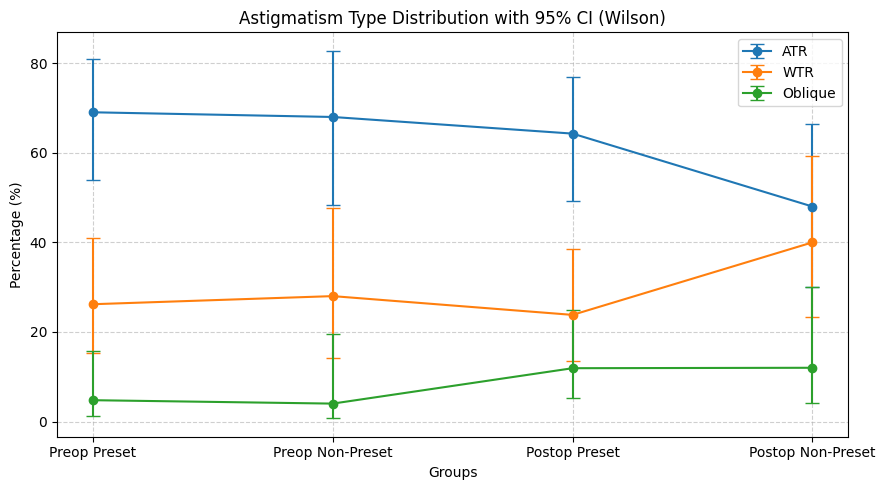

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# X-axis labels
x = ["Preop Preset", "Preop Non-Preset", "Postop Preset", "Postop Non-Preset"]

# Counts
ATR = np.array([29, 17, 27, 12])
WTR = np.array([11, 7, 10, 10])
OBL = np.array([2, 1, 5, 3])

# Totals per column
N = np.array([42, 25, 42, 25])

# Function to compute Wilson CI
def get_ci(n, N):
    p = n / N
    low, high = proportion_confint(n, N, method='wilson')
    return p*100, (p - low)*100, (high - p)*100  # % and asymmetric errors

# Compute values
ATR_p, ATR_err_low, ATR_err_high = get_ci(ATR, N)
WTR_p, WTR_err_low, WTR_err_high = get_ci(WTR, N)
OBL_p, OBL_err_low, OBL_err_high = get_ci(OBL, N)

# Plot
plt.figure(figsize=(9,5))

plt.errorbar(x, ATR_p, yerr=[ATR_err_low, ATR_err_high], fmt='-o', capsize=5, label='ATR')
plt.errorbar(x, WTR_p, yerr=[WTR_err_low, WTR_err_high], fmt='-o', capsize=5, label='WTR')
plt.errorbar(x, OBL_p, yerr=[OBL_err_low, OBL_err_high], fmt='-o', capsize=5, label='Oblique')

plt.ylabel("Percentage (%)")
plt.xlabel("Groups")
plt.title("Astigmatism Type Distribution with 95% CI (Wilson)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [45]:
import numpy as np
from scipy.stats import chi2_contingency

# Contingency table
table = np.array([
    [29, 11, 2],
    [17, 7, 1],
    [27, 10, 5],
    [12, 10, 3]
])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)
print("\nExpected frequencies:\n", expected)

Chi-square value: 5.090405210888184
Degrees of freedom: 6
P-value: 0.5322714408124603

Expected frequencies:
 [[26.64179104 11.91044776  3.44776119]
 [15.85820896  7.08955224  2.05223881]
 [26.64179104 11.91044776  3.44776119]
 [15.85820896  7.08955224  2.05223881]]


In [46]:
groups = ["preop_preset", "preop_nonpreset", "postop_preset", "postop_nonpreset"]



###
Drop in M → surgical effectiveness

J0 → toward 0 → reduction in regular astigmatism

J45 change → surgically induced torque

In [47]:
# Median values
M = [
    preop_preset['M'].median(),
    postop_preset['M'].median(),
    preop_nonpreset['M'].median(),
    postop_nonpreset['M'].median()
]

J0 = [
    preop_preset['J0'].median(),
    postop_preset['J0'].median(),
    preop_nonpreset['J0'].median(),
    postop_nonpreset['J0'].median()
]

J45 = [
    preop_preset['J45'].median(),
    postop_preset['J45'].median(),
    preop_nonpreset['J45'].median(),
    postop_nonpreset['J45'].median()
]

In [48]:
# IQR calculation
def get_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return q1, q3

M_q1, M_q3 = zip(*[
    get_iqr(preop_preset['M']),
    get_iqr(postop_preset['M']),
    get_iqr(preop_nonpreset['M']),
    get_iqr(postop_nonpreset['M'])
])

J0_q1, J0_q3 = zip(*[
    get_iqr(preop_preset['J0']),
    get_iqr(postop_preset['J0']),
    get_iqr(preop_nonpreset['J0']),
    get_iqr(postop_nonpreset['J0'])
])

J45_q1, J45_q3 = zip(*[
    get_iqr(preop_preset['J45']),
    get_iqr(postop_preset['J45']),
    get_iqr(preop_nonpreset['J45']),
    get_iqr(postop_nonpreset['J45'])
])

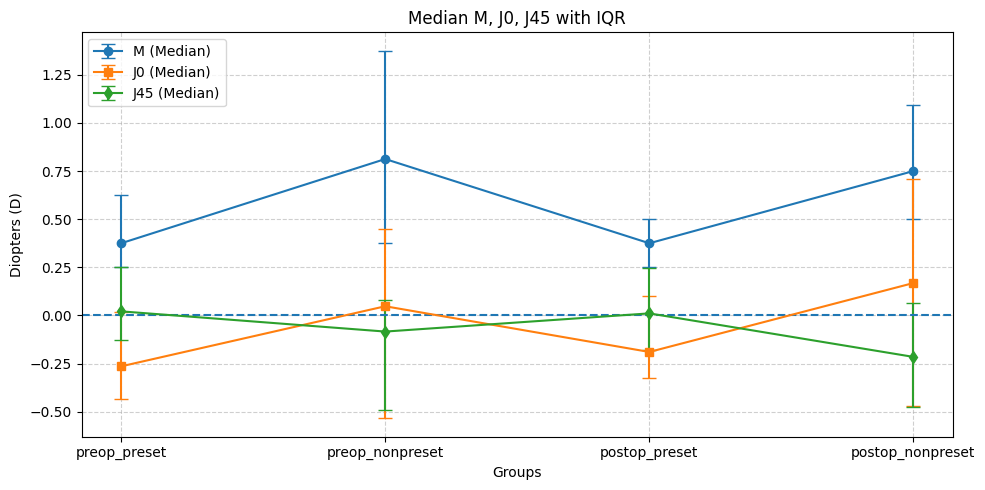

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# groups = ["Pre-Preset", "Pre-NonPreset", "Post-Preset", "Post-NonPreset"]

plt.figure(figsize=(10,5))

# Convert to numpy for error bars
M = np.array(M)
J0 = np.array(J0)
J45 = np.array(J45)

M_err = [M - np.array(M_q1), np.array(M_q3) - M]
J0_err = [J0 - np.array(J0_q1), np.array(J0_q3) - J0]
J45_err = [J45 - np.array(J45_q1), np.array(J45_q3) - J45]

plt.errorbar(groups, M, yerr=M_err, fmt='o-', capsize=5, label='M (Median)')
plt.errorbar(groups, J0, yerr=J0_err, fmt='s-', capsize=5, label='J0 (Median)')
plt.errorbar(groups, J45, yerr=J45_err, fmt='d-', capsize=5, label='J45 (Median)')

plt.axhline(0, linestyle='--')

plt.xlabel("Groups")
plt.ylabel("Diopters (D)")
plt.title("Median M, J0, J45 with IQR")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1213/2043495185.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_M, labels=labels)


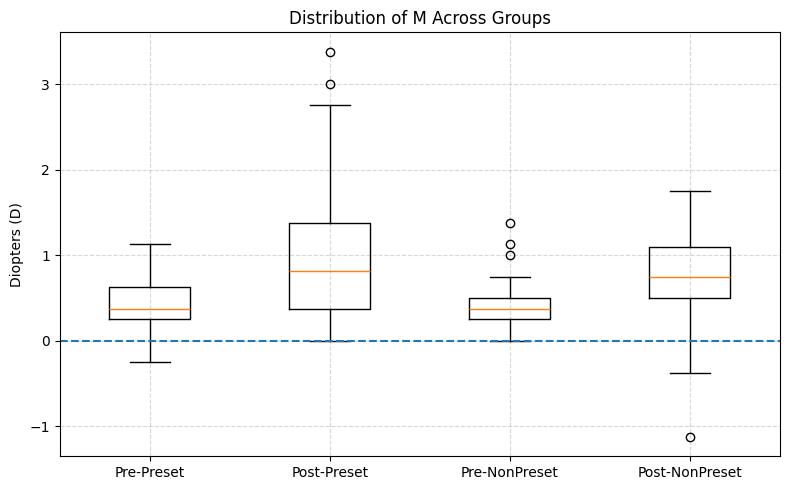

In [50]:
import matplotlib.pyplot as plt

data_M = [
    preop_preset['M'],
    postop_preset['M'],
    preop_nonpreset['M'],
    postop_nonpreset['M']
]

labels = ["Pre-Preset", "Post-Preset", "Pre-NonPreset", "Post-NonPreset"]

plt.figure(figsize=(8,5))
plt.boxplot(data_M, labels=labels)

plt.axhline(0, linestyle='--')

plt.ylabel("Diopters (D)")
plt.title("Distribution of M Across Groups")

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1213/2720797084.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_J0, labels=labels)


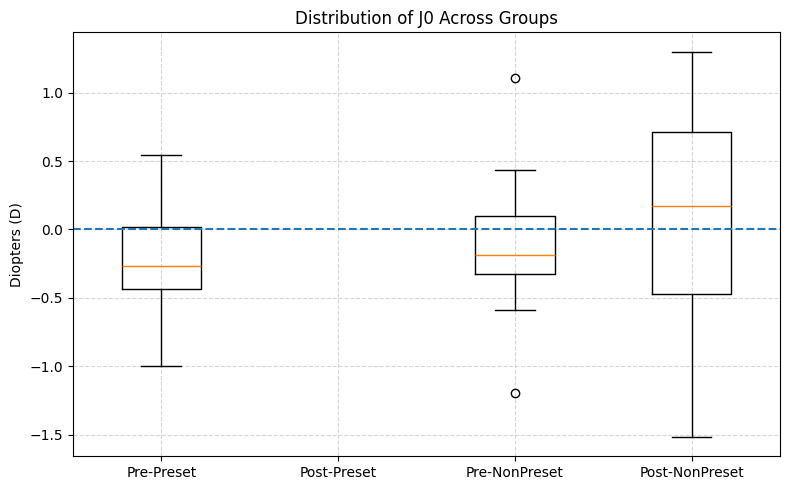

In [51]:
data_J0 = [
    preop_preset['J0'],
    postop_preset['J0'],
    preop_nonpreset['J0'],
    postop_nonpreset['J0']
]

plt.figure(figsize=(8,5))
plt.boxplot(data_J0, labels=labels)

plt.axhline(0, linestyle='--')

plt.ylabel("Diopters (D)")
plt.title("Distribution of J0 Across Groups")

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1213/3016724926.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_J45, labels=labels)


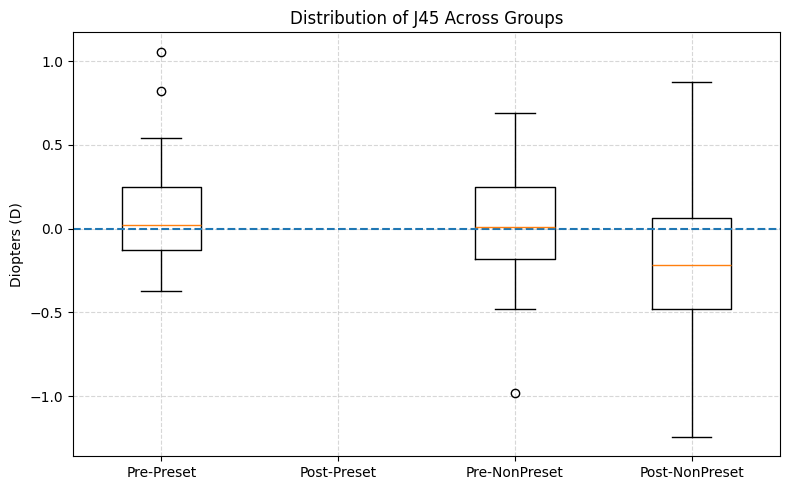

In [52]:
data_J45 = [
    preop_preset['J45'],
    postop_preset['J45'],
    preop_nonpreset['J45'],
    postop_nonpreset['J45']
]

plt.figure(figsize=(8,5))
plt.boxplot(data_J45, labels=labels)

plt.axhline(0, linestyle='--')

plt.ylabel("Diopters (D)")
plt.title("Distribution of J45 Across Groups")

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1213/936877452.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_M, labels=labels)
/tmp/ipykernel_1213/936877452.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_J0, labels=labels)
/tmp/ipykernel_1213/936877452.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(data_J45, labels=labels)


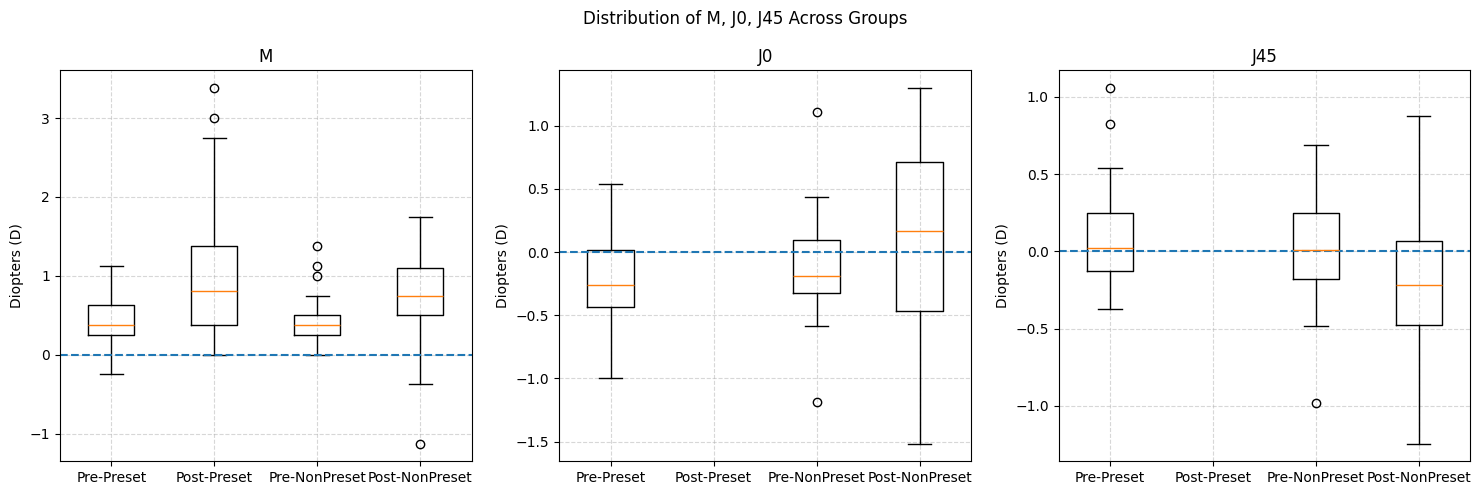

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# M
axes[0].boxplot(data_M, labels=labels)
axes[0].axhline(0, linestyle='--')
axes[0].set_title("M")

# J0
axes[1].boxplot(data_J0, labels=labels)
axes[1].axhline(0, linestyle='--')
axes[1].set_title("J0")

# J45
axes[2].boxplot(data_J45, labels=labels)
axes[2].axhline(0, linestyle='--')
axes[2].set_title("J45")

for ax in axes:
    ax.set_ylabel("Diopters (D)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Distribution of M, J0, J45 Across Groups")

plt.tight_layout()
plt.show()

In [54]:
from scipy.stats import wilcoxon

# Example: M (Preset group)
stat, p = wilcoxon(preop_preset['M'], postop_preset['M'])

print("Wilcoxon test statistic:", stat)
print("P-value:", p)

Wilcoxon test statistic: 114.0
P-value: 0.0003303581621569342


In [55]:
# J0
wilcoxon(preop_preset['J0'], postop_preset['J0'])

# J45
wilcoxon(preop_preset['J45'], postop_preset['J45'])

WilcoxonResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [56]:
from scipy.stats import mannwhitneyu

# M
stat_M, p_M = mannwhitneyu(postop_preset['M'], postop_nonpreset['M'], alternative='two-sided')

# J0
stat_J0, p_J0 = mannwhitneyu(postop_preset['J0'], postop_nonpreset['J0'], alternative='two-sided')

# J45
stat_J45, p_J45 = mannwhitneyu(postop_preset['J45'], postop_nonpreset['J45'], alternative='two-sided')

print("M: U =", stat_M, "p =", p_M)
print("J0: U =", stat_J0, "p =", p_J0)
print("J45: U =", stat_J45, "p =", p_J45)

M: U = 596.0 p = 0.5311423384999923
J0: U = nan p = nan
J45: U = nan p = nan


In [57]:
preop_preset.columns, postop_preset.columns, preop_nonpreset.columns, postop_nonpreset.columns,

(Index(['Name', 'Age', 'Gender ', 'Operating eye', 'R1', 'R2', 'A1', 'M',
        'cylinder', 'steepaxis', 'alpha', 'J0', 'J45', 'Astigmatism_Type'],
       dtype='object'),
 Index(['Name', 'Age', 'Gender ', 'Operating eye', 'R1', 'R2', 'A1', 'M',
        'cylinder', 'steepaxis', 'alpha', 'J0', 'J45', 'Astigmatism_Type'],
       dtype='object'),
 Index(['Name', 'Age', 'Gender', 'Operating eye', 'R1', 'R2', 'A1', 'M',
        'cylinder', 'steepaxis', 'alpha', 'J0', 'J45', 'Astigmatism_Type'],
       dtype='object'),
 Index(['Name', 'Age', 'Gender', 'operating eye', 'R1', 'R2', 'A1', 'M',
        'cylinder', 'steepaxis', 'alpha', 'J0', 'J45', 'Astigmatism_Type'],
       dtype='object'))

### Mean K

In [58]:
preop_preset['meanK'] = (preop_preset['R1'] + preop_preset['R2']) / 2
preop_nonpreset['meanK'] = (preop_nonpreset['R1'] + preop_nonpreset['R2']) / 2
postop_preset['meanK'] = (postop_preset['R1'] + postop_preset['R2']) /2
postop_nonpreset['meanK'] = (postop_nonpreset['R1'] + postop_nonpreset['R2'])/2


In [59]:
preop_preset['meanK'].describe(),preop_nonpreset['meanK'].describe(),postop_preset['meanK'].describe(),postop_nonpreset['meanK'].describe()




(count    42.000000
 mean     44.491071
 std       1.535503
 min      40.500000
 25%      43.531250
 50%      44.500000
 75%      45.625000
 max      47.250000
 Name: meanK, dtype: float64,
 count    26.000000
 mean     44.451923
 std       1.920311
 min      40.875000
 25%      43.156250
 50%      44.625000
 75%      45.750000
 max      48.500000
 Name: meanK, dtype: float64,
 count    42.000000
 mean     44.738202
 std       1.969372
 min      38.125000
 25%      43.687500
 50%      44.625000
 75%      46.187500
 max      48.625000
 Name: meanK, dtype: float64,
 count    26.000000
 mean     44.399038
 std       1.991237
 min      40.250000
 25%      43.312500
 50%      44.437500
 75%      45.531250
 max      48.875000
 Name: meanK, dtype: float64)

In [60]:
from scipy.stats import shapiro

groups = {
    'Preop Preset': preop_preset['meanK'],
    'Preop Non-preset': preop_nonpreset['meanK'],
    'Postop Preset': postop_preset['meanK'],
    'Postop Non-preset': postop_nonpreset['meanK']
}

for name, data in groups.items():
    stat, p = shapiro(data.dropna())
    print(f'\n{name}')
    print(f'Shapiro statistic = {stat:.3f}')
    print(f'p value = {p:.4f}')


Preop Preset
Shapiro statistic = 0.968
p value = 0.2881

Preop Non-preset
Shapiro statistic = 0.982
p value = 0.9074

Postop Preset
Shapiro statistic = 0.958
p value = 0.1228

Postop Non-preset
Shapiro statistic = 0.971
p value = 0.6550


In [61]:
from scipy.stats import ttest_ind

# Preop comparison
t, p = ttest_ind(preop_preset['meanK'],
                 preop_nonpreset['meanK'],
                 nan_policy='omit')

print("Preop meanK")
print(f"t = {t:.3f}, p = {p:.4f}")

# Postop comparison
t, p = ttest_ind(postop_preset['meanK'],
                 postop_nonpreset['meanK'],
                 nan_policy='omit')

print("\nPostop meanK")
print(f"t = {t:.3f}, p = {p:.4f}")

Preop meanK
t = 0.093, p = 0.9264

Postop meanK
t = 0.687, p = 0.4943


### Mean K t test

In [62]:
from scipy import stats

# Paired t-test for preset group
t_stat_preset, p_value_preset = stats.ttest_rel(preop_preset['meanK'], postop_preset['meanK'])

# Paired t-test for non-preset group
t_stat_nonpreset, p_value_nonpreset = stats.ttest_rel(preop_nonpreset['meanK'], postop_nonpreset['meanK'])

print("Preset group: t =", t_stat_preset, ", p =", p_value_preset)
print("Non-preset group: t =", t_stat_nonpreset, ", p =", p_value_nonpreset)

Preset group: t = -1.30187459031936 , p = 0.20022643933863316
Non-preset group: t = 0.19784556662737404 , p = 0.8447658139846045


In [63]:
from scipy import stats

# Independent t-test for pre-op groups
t_stat_preop, p_value_preop = stats.ttest_ind(preop_preset['meanK'], preop_nonpreset['meanK'], equal_var=False)

# Independent t-test for post-op groups
t_stat_postop, p_value_postop = stats.ttest_ind(postop_preset['meanK'], postop_nonpreset['meanK'], equal_var=False)

print("Pre-op groups: t =", t_stat_preop, ", p =", p_value_preop)
print("Post-op groups: t =", t_stat_postop, ", p =", p_value_postop)

Pre-op groups: t = 0.08798649303900193 , p = 0.9302825357481397
Post-op groups: t = 0.6854322177821772 , p = 0.4960772014339525


In [64]:
preop_preset.head()

,Name,Age,Gender,Operating eye,R1,R2,A1,M,cylinder,steepaxis,alpha,J0,J45,Astigmatism_Type,meanK
0,Deviramma,55,F,RE,43.50,43.75,35,0.125,0.25,125,2.181662,0.042753,0.117462,WTR,43.625
1,Sakamma,69,F,RE,43.00,44.00,75,0.500,1.00,165,2.879793,-0.433013,0.250000,ATR,43.500
2,Malamma,64,F,LE,44.50,46.00,95,0.750,1.50,5,0.087266,-0.738606,-0.130236,ATR,45.250
3,Rajkumar,57,M,RE,43.25,44.50,60,0.625,1.25,150,2.617994,-0.312500,0.541266,ATR,43.875
4,Chanappa,79,M,RE,42.25,43.75,100,0.750,1.50,10,0.174533,-0.704769,-0.256515,ATR,43.000


In [65]:
preop_preset['meanK'].describe(), preop_nonpreset['meanK'].describe(), postop_preset['meanK'].describe(), postop_nonpreset['meanK'].describe()

(count    42.000000
 mean     44.491071
 std       1.535503
 min      40.500000
 25%      43.531250
 50%      44.500000
 75%      45.625000
 max      47.250000
 Name: meanK, dtype: float64,
 count    26.000000
 mean     44.451923
 std       1.920311
 min      40.875000
 25%      43.156250
 50%      44.625000
 75%      45.750000
 max      48.500000
 Name: meanK, dtype: float64,
 count    42.000000
 mean     44.738202
 std       1.969372
 min      38.125000
 25%      43.687500
 50%      44.625000
 75%      46.187500
 max      48.625000
 Name: meanK, dtype: float64,
 count    26.000000
 mean     44.399038
 std       1.991237
 min      40.250000
 25%      43.312500
 50%      44.437500
 75%      45.531250
 max      48.875000
 Name: meanK, dtype: float64)

In [66]:
import pandas as pd

groups = {
    "preop_preset": preop_preset['meanK'],
    "preop_nonpreset": preop_nonpreset['meanK'],
    "postop_preset": postop_preset['meanK'],
    "postop_nonpreset": postop_nonpreset['meanK']
}

results = []

for name, data in groups.items():
    median = data.median()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    skew = data.skew()
    kurt = data.kurt()

    results.append([name, median, iqr, skew, kurt])

summary_df = pd.DataFrame(
    results,
    columns=["Group", "Median", "IQR", "Skewness", "Kurtosis"]
)

print(summary_df)

              Group   Median      IQR  Skewness  Kurtosis
0      preop_preset  44.5000  2.09375 -0.400599 -0.216900
1   preop_nonpreset  44.6250  2.59375  0.036302 -0.323354
2     postop_preset  44.6250  2.50000 -0.662575  1.748032
3  postop_nonpreset  44.4375  2.21875  0.063405  0.599604


In [67]:
summary_df_rounded = summary_df.copy()

summary_df_rounded["Median"] = summary_df_rounded["Median"].round(2)
summary_df_rounded["IQR"] = summary_df_rounded["IQR"].round(2)
summary_df_rounded["Skewness"] = summary_df_rounded["Skewness"].round(2)
summary_df_rounded["Kurtosis"] = summary_df_rounded["Kurtosis"].round(2)

print(summary_df_rounded)

              Group  Median   IQR  Skewness  Kurtosis
0      preop_preset   44.50  2.09     -0.40     -0.22
1   preop_nonpreset   44.62  2.59      0.04     -0.32
2     postop_preset   44.62  2.50     -0.66      1.75
3  postop_nonpreset   44.44  2.22      0.06      0.60


In [68]:
from scipy.stats import shapiro
import pandas as pd

groups = {
    "Preop preset": preop_preset["meanK"],
    "Preop nonpreset": preop_nonpreset["meanK"],
    "Postop preset": postop_preset["meanK"],
    "Postop nonpreset": postop_nonpreset["meanK"]
}

results = []

for name, data in groups.items():
    stat, p = shapiro(data.dropna())  # drop NA just in case
    results.append([name, stat, p])

shapiro_df = pd.DataFrame(results, columns=["Group", "W statistic", "p-value"])

print(shapiro_df)

              Group  W statistic   p-value
0      Preop preset     0.968250  0.288112
1   Preop nonpreset     0.981682  0.907440
2     Postop preset     0.957769  0.122831
3  Postop nonpreset     0.971214  0.655021


In [69]:
shapiro_df_round = shapiro_df.copy()
shapiro_df_round["W statistic"] = shapiro_df_round["W statistic"].round(4)
shapiro_df_round["p-value"] = shapiro_df_round["p-value"].round(4)

print(shapiro_df_round)

              Group  W statistic  p-value
0      Preop preset       0.9682   0.2881
1   Preop nonpreset       0.9817   0.9074
2     Postop preset       0.9578   0.1228
3  Postop nonpreset       0.9712   0.6550


### independant t test between groups foar mean K

In [70]:
from scipy.stats import ttest_ind

t1, p1 = ttest_ind(preop_preset["meanK"], preop_nonpreset["meanK"], equal_var=False)

print("Preop (preset vs nonpreset): t =", t1, "p =", p1)

t2, p2 = ttest_ind(postop_preset["meanK"], postop_nonpreset["meanK"], equal_var=False)

print("Postop (preset vs nonpreset): t =", t2, "p =", p2)

Preop (preset vs nonpreset): t = 0.08798649303900193 p = 0.9302825357481397
Postop (preset vs nonpreset): t = 0.6854322177821772 p = 0.4960772014339525


### within groups

In [71]:
from scipy.stats import ttest_rel

t3, p3 = ttest_rel(preop_preset["meanK"], postop_preset["meanK"])

print("Preset (pre vs post): t =", t3, "p =", p3)

t4, p4 = ttest_rel(preop_nonpreset["meanK"], postop_nonpreset["meanK"])

print("Nonpreset (pre vs post): t =", t4, "p =", p4)

Preset (pre vs post): t = -1.30187459031936 p = 0.20022643933863316
Nonpreset (pre vs post): t = 0.19784556662737404 p = 0.8447658139846045


### Best overall test (recommended): Two-way ANOVA

In [72]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.concat([
    preop_preset.assign(Time="Preop", Group="Preset"),
    preop_nonpreset.assign(Time="Preop", Group="Nonpreset"),
    postop_preset.assign(Time="Postop", Group="Preset"),
    postop_nonpreset.assign(Time="Postop", Group="Nonpreset")
])

model = ols("meanK ~ C(Group) * C(Time)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                      sum_sq     df         F    PR(>F)
C(Group)            1.149171    1.0  0.339353  0.561197
C(Time)             0.596184    1.0  0.176054  0.675468
C(Group):C(Time)    0.722722    1.0  0.213421  0.644859
Residual          446.999581  132.0       NaN       NaN


###
A two-way ANOVA showed no significant main effect of Group (F = 0.34, p = 0.56),

Time (F = 0.18, p = 0.68), or

Group × Time interaction (F = 0.21, p = 0.64), indicating that meanK did not differ between groups, did not change over time, and did not show differential change between groups.

### Cylinder analysis

In [73]:
preop_preset['cylinder'] = preop_preset['R2'] - preop_preset['R1']
preop_nonpreset['cylinder'] = preop_nonpreset['R2'] - preop_nonpreset['R1']
postop_preset['cylinder'] = postop_preset['R2'] - postop_preset['R1']
postop_nonpreset['cylinder'] = postop_nonpreset['R2'] - postop_nonpreset['R1']

In [74]:
import pandas as pd

def extended_stats(x):
    return pd.Series({
        "Count": x.count(),
        "Mean": x.mean(),
        "SD": x.std(ddof=1),
        "Median": x.median(),
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "Min": x.min(),
        "Max": x.max(),
        "Skewness": x.skew(),
        "Kurtosis": x.kurt()
    })

groups = {
    "Preop preset": preop_preset["cylinder"],
    "Preop nonpreset": preop_nonpreset["cylinder"],
    "Postop preset": postop_preset["cylinder"],
    "Postop nonpreset": postop_nonpreset["cylinder"]
}

cylinder_summary = pd.DataFrame({name: extended_stats(data) for name, data in groups.items()}).T

print(cylinder_summary)

cylinder_summary_round = cylinder_summary.copy().round(2)
print(cylinder_summary_round)

                  Count      Mean        SD  Median     IQR   Min    Max  \
Preop preset       42.0  0.863095  0.560929   0.750  0.7500 -0.50  2.250   
Preop nonpreset    26.0  0.923077  0.619553   0.750  0.5000  0.00  2.750   
Postop preset      42.0  2.083548  1.755079   1.625  2.0000  0.00  6.759   
Postop nonpreset   26.0  1.451923  1.216592   1.500  1.1875 -2.25  3.500   

                  Skewness  Kurtosis  
Preop preset      0.310594  0.203198  
Preop nonpreset   1.476192  2.476267  
Postop preset     1.016086  0.257809  
Postop nonpreset -1.035270  2.484278  
                  Count  Mean    SD  Median   IQR   Min   Max  Skewness  \
Preop preset       42.0  0.86  0.56    0.75  0.75 -0.50  2.25      0.31   
Preop nonpreset    26.0  0.92  0.62    0.75  0.50  0.00  2.75      1.48   
Postop preset      42.0  2.08  1.76    1.62  2.00  0.00  6.76      1.02   
Postop nonpreset   26.0  1.45  1.22    1.50  1.19 -2.25  3.50     -1.04   

                  Kurtosis  
Preop preset       

In [75]:
from scipy.stats import shapiro
import pandas as pd

groups = {
    "Preop preset": preop_preset["cylinder"],
    "Preop nonpreset": preop_nonpreset["cylinder"],
    "Postop preset": postop_preset["cylinder"],
    "Postop nonpreset": postop_nonpreset["cylinder"]
}

results = []

for name, data in groups.items():
    stat, p = shapiro(data.dropna())
    results.append([name, stat, p])

shapiro_cylinder = pd.DataFrame(results, columns=["Group", "W statistic", "p-value"])

print(shapiro_cylinder)

              Group  W statistic   p-value
0      Preop preset     0.961493  0.166995
1   Preop nonpreset     0.855494  0.001821
2     Postop preset     0.895988  0.001094
3  Postop nonpreset     0.931971  0.086346


### within group mann whitney for cylinder

In [76]:
from scipy.stats import mannwhitneyu

mannwhitneyu(preop_preset["cylinder"], postop_preset["cylinder"])


MannwhitneyuResult(statistic=np.float64(508.0), pvalue=np.float64(0.0007859548362681167))

In [77]:
mannwhitneyu(preop_nonpreset["cylinder"], postop_nonpreset["cylinder"])

MannwhitneyuResult(statistic=np.float64(187.5), pvalue=np.float64(0.005713890628355378))

In [78]:
mannwhitneyu(preop_preset["cylinder"], preop_nonpreset["cylinder"])

MannwhitneyuResult(statistic=np.float64(537.0), pvalue=np.float64(0.9134561089168611))

In [79]:
mannwhitneyu(postop_preset["cylinder"], postop_nonpreset["cylinder"])

MannwhitneyuResult(statistic=np.float64(596.0), pvalue=np.float64(0.5311423384999923))

In [80]:
mannwhitneyu(preop_preset["cylinder"], postop_preset["cylinder"])



MannwhitneyuResult(statistic=np.float64(508.0), pvalue=np.float64(0.0007859548362681167))

In [81]:
mannwhitneyu(preop_nonpreset["cylinder"], postop_nonpreset["cylinder"])



MannwhitneyuResult(statistic=np.float64(187.5), pvalue=np.float64(0.005713890628355378))

### The distribution of corneal cylinder did not differ significantly between groups (Mann–Whitney U = 537.0, p = 0.913), indicating no evidence of a group effect on astigmatism.

In [82]:
from scipy.stats import wilcoxon

wilcoxon(preop_preset["cylinder"], postop_preset["cylinder"])

WilcoxonResult(statistic=np.float64(114.0), pvalue=np.float64(0.0003303581621569342))

In [83]:
wilcoxon(preop_nonpreset["cylinder"], postop_nonpreset["cylinder"])

WilcoxonResult(statistic=np.float64(53.5), pvalue=np.float64(0.017496485696978155))

### A Wilcoxon signed-rank test showed a significant difference in cylinder between preoperative and postoperative measurements (W = 114.0, p = 0.00033), indicating a significant change in astigmatism following surgery.


### | Variable                  | Result                            |
| ------------------------- | --------------------------------- |
| MeanK                     | No difference (ANOVA)
           |
| Cylinder (between groups) | No difference (Mann–Whitney)  
   |
| Cylinder (pre vs post)    | **Significant change (Wilcoxon)** |

In [84]:
from scipy.stats import wilcoxon

x = preop_preset["cylinder"]
y = postop_preset["cylinder"]

w = wilcoxon(x, y)

n = len(x)

# rank-biserial correlation
r_rb = 1 - (2 * w.statistic) / (n * (n + 1) / 2)

print("Wilcoxon statistic:", w.statistic)
print("p-value:", w.pvalue)
print("Rank-biserial r:", r_rb)

Wilcoxon statistic: 114.0
p-value: 0.0003303581621569342
Rank-biserial r: 0.7475083056478405


In [85]:
x = preop_nonpreset["cylinder"]
y = postop_nonpreset["cylinder"]

w = wilcoxon(x, y)

n = len(x)

# rank-biserial correlation
r_rb = 1 - (2 * w.statistic) / (n * (n + 1) / 2)

print("Wilcoxon statistic:", w.statistic)
print("p-value:", w.pvalue)
print("Rank-biserial r:", r_rb)

Wilcoxon statistic: 53.5
p-value: 0.017496485696978155
Rank-biserial r: 0.6951566951566952


### A Wilcoxon signed-rank test demonstrated a significant change in corneal cylinder between preoperative and postoperative measurements (W = 114.0, p = 0.00033), with a large effect size (r = 0.75), indicating a substantial reduction in astigmatism following surgery.

### Both preset and non-preset groups demonstrated significant improvements from preoperative to postoperative measurements with large effect sizes, while no significant differences were observed between groups at baseline or postoperatively.


### Mann whitney for meanK

In [86]:
mannwhitneyu(preop_preset["meanK"], postop_preset["meanK"])

MannwhitneyuResult(statistic=np.float64(792.5), pvalue=np.float64(0.42559494969824885))

In [87]:
mannwhitneyu(preop_nonpreset["meanK"], postop_nonpreset["meanK"])

MannwhitneyuResult(statistic=np.float64(341.0), pvalue=np.float64(0.9634673782652122))

In [88]:
mannwhitneyu(preop_preset["meanK"], preop_nonpreset["meanK"])

MannwhitneyuResult(statistic=np.float64(565.0), pvalue=np.float64(0.8152338215165466))

In [89]:
mannwhitneyu(postop_preset["meanK"], postop_nonpreset["meanK"])

MannwhitneyuResult(statistic=np.float64(611.0), pvalue=np.float64(0.41537951864885503))

In [90]:
x = preop_preset["meanK"]
y = postop_preset["meanK"]

w = wilcoxon(x, y)

n = len(x)

# rank-biserial correlation
r_rb = 1 - (2 * w.statistic) / (n * (n + 1) / 2)

print("Wilcoxon statistic:", w.statistic)
print("p-value:", w.pvalue)
print("Rank-biserial r:", r_rb)

Wilcoxon statistic: 229.5
p-value: 0.16081893988480167
Rank-biserial r: 0.49169435215946844


In [91]:
x = preop_nonpreset["meanK"]
y = postop_nonpreset["meanK"]

w = wilcoxon(x, y)

n = len(x)

# rank-biserial correlation
r_rb = 1 - (2 * w.statistic) / (n * (n + 1) / 2)

print("Wilcoxon statistic:", w.statistic)
print("p-value:", w.pvalue)
print("Rank-biserial r:", r_rb)

Wilcoxon statistic: 143.5
p-value: 0.6086697804749609
Rank-biserial r: 0.18233618233618232


In [92]:
variables = ["M", "J0", "J45"]

groups = {
    "Preop preset": preop_preset,
    "Preop nonpreset": preop_nonpreset,
    "Postop preset": postop_preset,
    "Postop nonpreset": postop_nonpreset
}

In [93]:
import pandas as pd

def extended_stats(x):
    return pd.Series({
        "Count": x.count(),
        "Mean": x.mean(),
        "SD": x.std(ddof=1),
        "Median": x.median(),
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "Min": x.min(),
        "Max": x.max(),
        "Skewness": x.skew(),
        "Kurtosis": x.kurt()
    })

desc_results = {}

for var in variables:
    desc_results[var] = pd.DataFrame({
        name: extended_stats(df[var].dropna())
        for name, df in groups.items()
    }).T

# Example: view M
desc_results["M"]

desc_results["M"].round(2)


,Count,Mean,SD,Median,IQR,Min,Max,Skewness,Kurtosis
Preop preset,42.0,0.43,0.28,0.38,0.38,-0.25,1.12,0.31,0.20
Preop nonpreset,26.0,0.46,0.31,0.38,0.25,0.00,1.38,1.48,2.48
Postop preset,42.0,1.04,0.88,0.81,1.00,0.00,3.38,1.02,0.26
Postop nonpreset,26.0,0.73,0.61,0.75,0.59,-1.12,1.75,-1.04,2.48


### Mean refractive power (M) showed an increase postoperatively in both groups, with greater variability observed in the preset group. Distributions were non-normal in several subgroups, suggesting heterogeneity in refractive response.


### M analysis

In [94]:
from scipy.stats import shapiro

for name, df in groups.items():
    stat, p = shapiro(df[var].dropna())
    print(f"{name}: W = {stat:.4f}, p = {p:.4f}")

Preop preset: W = 0.9210, p = 0.0065
Preop nonpreset: W = 0.9534, p = 0.2786
Postop preset: W = 0.8811, p = 0.0061
Postop nonpreset: W = 0.9662, p = 0.5269


### Wilcoxan for M

In [95]:
x = preop_preset["M"]
y = postop_preset["M"]

w = wilcoxon(x, y)

n = len(x)

# rank-biserial correlation
r_rb = 1 - (2 * w.statistic) / (n * (n + 1) / 2)

print("Wilcoxon statistic:", w.statistic)
print("p-value:", w.pvalue)
print("Rank-biserial r:", r_rb)

Wilcoxon statistic: 114.0
p-value: 0.0003303581621569342
Rank-biserial r: 0.7475083056478405


In [96]:
x = preop_nonpreset["M"]
y = postop_nonpreset["M"]

w = wilcoxon(x, y)

n = len(x)

# rank-biserial correlation
r_rb = 1 - (2 * w.statistic) / (n * (n + 1) / 2)

print("Wilcoxon statistic:", w.statistic)
print("p-value:", w.pvalue)
print("Rank-biserial r:", r_rb)

Wilcoxon statistic: 53.5
p-value: 0.017496485696978155
Rank-biserial r: 0.6951566951566952


In [97]:
mannwhitneyu(preop_preset["M"], preop_nonpreset["M"])

MannwhitneyuResult(statistic=np.float64(537.0), pvalue=np.float64(0.9134561089168611))

In [98]:
mannwhitneyu(postop_preset["M"], postop_nonpreset["M"])

MannwhitneyuResult(statistic=np.float64(596.0), pvalue=np.float64(0.5311423384999923))

In [99]:
from scipy.stats import shapiro

def shapiro_table(var):
    out = []
    for name, df in groups.items():
        stat, p = shapiro(df[var].dropna())
        out.append([name, stat, p])
    return pd.DataFrame(out, columns=["Group", "W statistic", "p-value"])

shapiro_M = shapiro_table("M")
shapiro_J0 = shapiro_table("J0")
shapiro_J45 = shapiro_table("J45")

print(shapiro_M)

              Group  W statistic   p-value
0      Preop preset     0.961493  0.166995
1   Preop nonpreset     0.855494  0.001821
2     Postop preset     0.895988  0.001094
3  Postop nonpreset     0.931971  0.086346


### The distribution of mean refractive power (M) was non-normal in several subgroups (Shapiro–Wilk, p < 0.05), particularly in the nonpreset and postoperative preset groups, indicating that non-parametric methods were appropriate for further analysis.

In [100]:
from scipy.stats import mannwhitneyu

def pairwise_mannwhitney(var):
    results = []

    comparisons = [
        ("Preop preset", "Preop nonpreset"),
        ("Postop preset", "Postop nonpreset")
    ]

    for g1, g2 in comparisons:
        x = groups[g1][var]
        y = groups[g2][var]

        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        results.append([var, g1, g2, stat, p])

    return pd.DataFrame(results, columns=["Variable", "Group1", "Group2", "U", "p-value"])

mw_M = pairwise_mannwhitney("M")
mw_J0 = pairwise_mannwhitney("J0")
mw_J45 = pairwise_mannwhitney("J45")

mw_M

,Variable,Group1,Group2,U,p-value
0,M,Preop preset,Preop nonpreset,537.0,0.913456
1,M,Postop preset,Postop nonpreset,596.0,0.531142


### Mann–Whitney U tests showed no significant differences in mean refractive power (M) between preset and nonpreset groups at either preoperative (U = 537.0, p = 0.913) or postoperative (U = 596.0, p = 0.531) timepoints.

In [101]:
from scipy.stats import wilcoxon

def wilcoxon_pre_post(var):
    results = []

    for group_name in ["preset", "nonpreset"]:
        pre = groups[f"Preop {group_name}"][var]
        post = groups[f"Postop {group_name}"][var]

        stat, p = wilcoxon(pre, post)

        results.append([var, group_name, stat, p])

    return pd.DataFrame(results, columns=["Variable", "Group", "W", "p-value"])

wil_M = wilcoxon_pre_post("M")
wil_J0 = wilcoxon_pre_post("J0")
wil_J45 = wilcoxon_pre_post("J45")

wil_M

,Variable,Group,W,p-value
0,M,preset,114.0,0.000330
1,M,nonpreset,53.5,0.017496


### Wilcoxon signed-rank testing demonstrated a significant increase in mean refractive power (M) from preoperative to postoperative measurements in both the preset group (W = 114.0, p = 0.00033) and the nonpreset group (W = 53.5, p = 0.0175), indicating a significant time effect.

In [102]:
def rank_biserial(pre, post, w_stat):
    n = len(pre)
    return 1 - (2 * w_stat) / (n * (n + 1) / 2)

def wilcoxon_effect(var):
    results = []

    for group_name in ["preset", "nonpreset"]:
        pre = groups[f"Preop {group_name}"][var]
        post = groups[f"Postop {group_name}"][var]

        w = wilcoxon(pre, post).statistic
        r = rank_biserial(pre, post, w)

        results.append([var, group_name, w, r])

    return pd.DataFrame(results, columns=["Variable", "Group", "W", "r"])

eff_M = wilcoxon_effect("M")
eff_J0 = wilcoxon_effect("J0")
eff_J45 = wilcoxon_effect("J45")

eff_M

,Variable,Group,W,r
0,M,preset,114.0,0.747508
1,M,nonpreset,53.5,0.695157


### Mean refractive power (M) showed a strong and statistically significant change from preoperative to postoperative measurements in both preset and nonpreset groups (r = 0.75 and r = 0.70, respectively), while no significant differences were observed between groups.

In [103]:
preop_preset.columns

Index(['Name', 'Age', 'Gender ', 'Operating eye', 'R1', 'R2', 'A1', 'M',
       'cylinder', 'steepaxis', 'alpha', 'J0', 'J45', 'Astigmatism_Type',
       'meanK'],
      dtype='object')

### Merge preop and postop (by patient)

In [104]:
import pandas as pd
import numpy as np

merged_preset = preop_preset.merge(
    postop_preset,
    on="Name",
    suffixes=('_pre', '_post')
)

merged_nonpreset = preop_nonpreset.merge(
    postop_nonpreset,
    on="Name",
    suffixes=('_pre', '_post')
)

### Compute ΔJ0 and ΔJ45 (SIA vector)

In [105]:
merged_preset["dJ0"] = merged_preset["J0_post"] - merged_preset["J0_pre"]
merged_preset["dJ45"] = merged_preset["J45_post"] - merged_preset["J45_pre"]

merged_nonpreset["dJ0"] = merged_nonpreset["J0_post"] - merged_nonpreset["J0_pre"]
merged_nonpreset["dJ45"] = merged_nonpreset["J45_post"] - merged_nonpreset["J45_pre"]

### SIA magnitude

In [106]:
merged_preset["SIA_magnitude"] = np.sqrt(merged_preset["dJ0"]**2 + merged_preset["dJ45"]**2)
merged_nonpreset["SIA_magnitude"] = np.sqrt(merged_nonpreset["dJ0"]**2 + merged_nonpreset["dJ45"]**2)

### SIA axis (Alpins method)

In [107]:
merged_preset["SIA_axis_rad"] = 0.5 * np.arctan2(merged_preset["dJ45"], merged_preset["dJ0"])
merged_preset["SIA_axis_deg"] = np.degrees(merged_preset["SIA_axis_rad"])
merged_preset["SIA_axis_deg"] = merged_preset["SIA_axis_deg"] % 180

merged_nonpreset["SIA_axis_rad"] = 0.5 * np.arctan2(merged_nonpreset["dJ45"], merged_nonpreset["dJ0"])
merged_nonpreset["SIA_axis_deg"] = np.degrees(merged_nonpreset["SIA_axis_rad"])
merged_nonpreset["SIA_axis_deg"] = merged_nonpreset["SIA_axis_deg"] % 180

### Final output

In [108]:
sia_results_preset = merged_preset[["Name", "SIA_magnitude", "SIA_axis_deg"]]
sia_results_nonpreset = merged_nonpreset[["Name", "SIA_magnitude", "SIA_axis_deg"]]

print("SIA Results for Preset Group:")
print(sia_results_preset.head())
print("\nSIA Results for Nonpreset Group:")
print(sia_results_nonpreset.head())

SIA Results for Preset Group:
        Name  SIA_magnitude  SIA_axis_deg
0  Deviramma       0.125000    125.000000
1    Sakamma       0.559017    151.717474
2    Malamma       2.375000      5.000000
3   Rajkumar       0.564260    102.698173
4  Madegowda       1.061779    121.379420

SIA Results for Nonpreset Group:
        Name  SIA_magnitude  SIA_axis_deg
0   Indramma       0.780625    161.948943
1  Ningaraju       0.823342    128.511772
2    DEVAMMA       0.239678    122.500000
3   SHIVANNA       0.748336    170.851960
4  JUBEDULLA       0.402302    131.511933


In [109]:
print("SIA magnitude and axis for Preset Group:")
print(merged_preset[["SIA_magnitude", "SIA_axis_deg"]].describe())
print("\nSIA magnitude and axis for Nonpreset Group:")
print(merged_nonpreset[["SIA_magnitude", "SIA_axis_deg"]].describe())

SIA magnitude and axis for Preset Group:
       SIA_magnitude  SIA_axis_deg
count      26.000000     26.000000
mean        0.971427     93.283706
std         0.698705     58.623041
min         0.125000      0.000000
25%         0.449760     42.500000
50%         0.906410    103.516824
75%         1.328765    148.041107
max         2.375000    168.562508

SIA magnitude and axis for Nonpreset Group:
       SIA_magnitude  SIA_axis_deg
count      18.000000     18.000000
mean        0.818566    108.170408
std         0.393998     52.338268
min         0.239678      0.858307
25%         0.555310     78.569226
50%         0.742049    128.005886
75%         1.001179    141.767012
max         1.969616    170.851960


### Cartesian plots for pre and post-operative preset groups

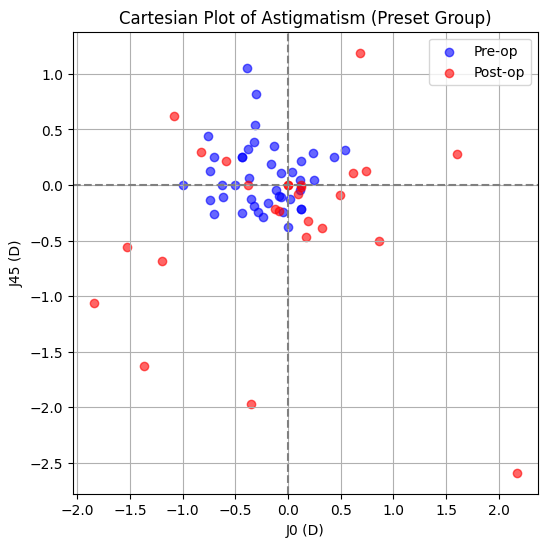

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Pre-op (preset)
plt.scatter(preop_preset['J0'], preop_preset['J45'],
            color='blue', alpha=0.6, label='Pre-op')

# Post-op (preset)
plt.scatter(postop_preset['J0'], postop_preset['J45'],
            color='red', alpha=0.6, label='Post-op')

# Axes lines at zero
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel('J0 (D)')
plt.ylabel('J45 (D)')
plt.title('Cartesian Plot of Astigmatism (Preset Group)')
plt.legend()
plt.grid(True)

plt.show()

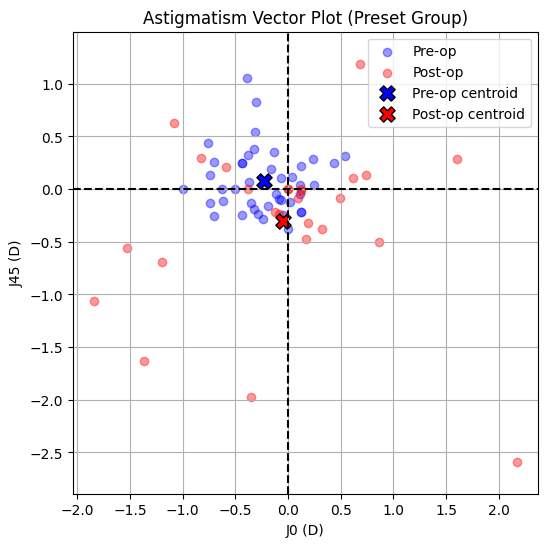

In [111]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(preop_preset['J0'], preop_preset['J45'],
            color='blue', alpha=0.4, label='Pre-op')
plt.scatter(postop_preset['J0'], postop_preset['J45'],
            color='red', alpha=0.4, label='Post-op')

# Centroids (means)
pre_mean_J0 = preop_preset['J0'].mean()
pre_mean_J45 = preop_preset['J45'].mean()

post_mean_J0 = postop_preset['J0'].mean()
post_mean_J45 = postop_preset['J45'].mean()

plt.scatter(pre_mean_J0, pre_mean_J45,
            color='blue', edgecolor='black', s=120, marker='X', label='Pre-op centroid')

plt.scatter(post_mean_J0, post_mean_J45,
            color='red', edgecolor='black', s=120, marker='X', label='Post-op centroid')

# Zero axes
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')

plt.xlabel('J0 (D)')
plt.ylabel('J45 (D)')
plt.title('Astigmatism Vector Plot (Preset Group)')
plt.legend()
plt.grid(True)

plt.axis('equal')  # important for correct geometry

plt.show()

In [112]:
# Pre-op centroid
pre_centroid_J0 = preop_preset['J0'].mean()
pre_centroid_J45 = preop_preset['J45'].mean()

# Post-op centroid
post_centroid_J0 = postop_preset['J0'].mean()
post_centroid_J45 = postop_preset['J45'].mean()

print("Pre-op centroid (J0, J45):", pre_centroid_J0, pre_centroid_J45)
print("Post-op centroid (J0, J45):", post_centroid_J0, post_centroid_J45)

Pre-op centroid (J0, J45): -0.23025145984471937 0.07665731964476352
Post-op centroid (J0, J45): -0.04432582701522659 -0.3061640894096534


In [113]:
print(f"Pre-op centroid: ({pre_centroid_J0:.3f}, {pre_centroid_J45:.3f}) D")
print(f"Post-op centroid: ({post_centroid_J0:.3f}, {post_centroid_J45:.3f}) D")

Pre-op centroid: (-0.230, 0.077) D
Post-op centroid: (-0.044, -0.306) D


In [114]:
delta_J0 = post_centroid_J0 - pre_centroid_J0
delta_J45 = post_centroid_J45 - pre_centroid_J45

print(f"Centroid shift: ({delta_J0:.3f}, {delta_J45:.3f}) D")

Centroid shift: (0.186, -0.383) D


### The astigmatic centroid shifted from (−0.230, 0.077) D preoperatively to (−0.044, −0.306) D postoperatively, corresponding to a vector change of 0.43 D predominantly along the J45 axis, indicating induction of oblique astigmatism.

In [115]:
# Pre-op centroid (non-preset)
pre_np_J0 = preop_nonpreset['J0'].mean()
pre_np_J45 = preop_nonpreset['J45'].mean()

# Post-op centroid (non-preset)
post_np_J0 = postop_nonpreset['J0'].mean()
post_np_J45 = postop_nonpreset['J45'].mean()

print(f"Pre-op centroid: ({pre_np_J0:.3f}, {pre_np_J45:.3f}) D")
print(f"Post-op centroid: ({post_np_J0:.3f}, {post_np_J45:.3f}) D")

Pre-op centroid: (-0.125, 0.016) D
Post-op centroid: (0.104, -0.163) D


In [116]:
delta_np_J0 = post_np_J0 - pre_np_J0
delta_np_J45 = post_np_J45 - pre_np_J45

print(f"Centroid shift: ({delta_np_J0:.3f}, {delta_np_J45:.3f}) D")

Centroid shift: (0.229, -0.179) D


In [117]:
import numpy as np

pre_mag = np.sqrt(pre_np_J0**2 + pre_np_J45**2)
post_mag = np.sqrt(post_np_J0**2 + post_np_J45**2)
shift_mag = np.sqrt(delta_np_J0**2 + delta_np_J45**2)

print(f"Pre-op magnitude: {pre_mag:.3f} D")
print(f"Post-op magnitude: {post_mag:.3f} D")
print(f"Shift magnitude: {shift_mag:.3f} D")

Pre-op magnitude: 0.127 D
Post-op magnitude: 0.193 D
Shift magnitude: 0.291 D


### Surgery does not simply reduce astigmatism; it redistributes it, predominantly toward the J45 (oblique) axis.

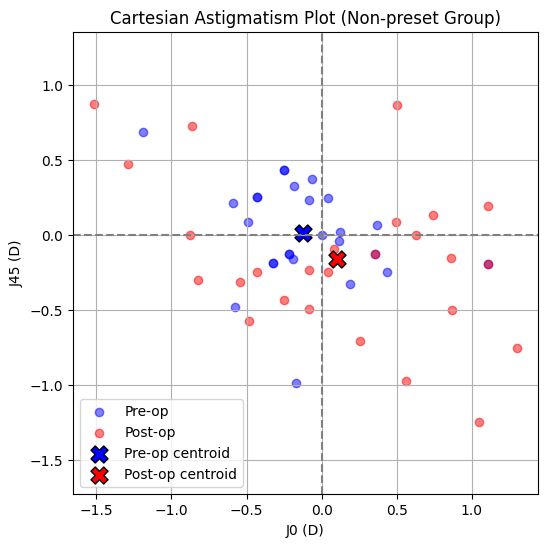

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(preop_nonpreset['J0'], preop_nonpreset['J45'],
            color='blue', alpha=0.5, label='Pre-op')

plt.scatter(postop_nonpreset['J0'], postop_nonpreset['J45'],
            color='red', alpha=0.5, label='Post-op')

# Centroids
pre_J0 = preop_nonpreset['J0'].mean()
pre_J45 = preop_nonpreset['J45'].mean()

post_J0 = postop_nonpreset['J0'].mean()
post_J45 = postop_nonpreset['J45'].mean()

plt.scatter(pre_J0, pre_J45,
            color='blue', marker='X', s=150, edgecolor='black',
            label='Pre-op centroid')

plt.scatter(post_J0, post_J45,
            color='red', marker='X', s=150, edgecolor='black',
            label='Post-op centroid')

# Zero reference lines
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.xlabel('J0 (D)')
plt.ylabel('J45 (D)')
plt.title('Cartesian Astigmatism Plot (Non-preset Group)')
plt.legend()
plt.grid(True)

plt.axis('equal')  # important for vector interpretation

plt.show()

In [119]:
import numpy as np

def to_polar(df):
    J0 = df['J0'].values
    J45 = df['J45'].values

    r = np.sqrt(J0**2 + J45**2)
    theta = 0.5 * np.arctan2(J45, J0)  # radians

    return r, theta

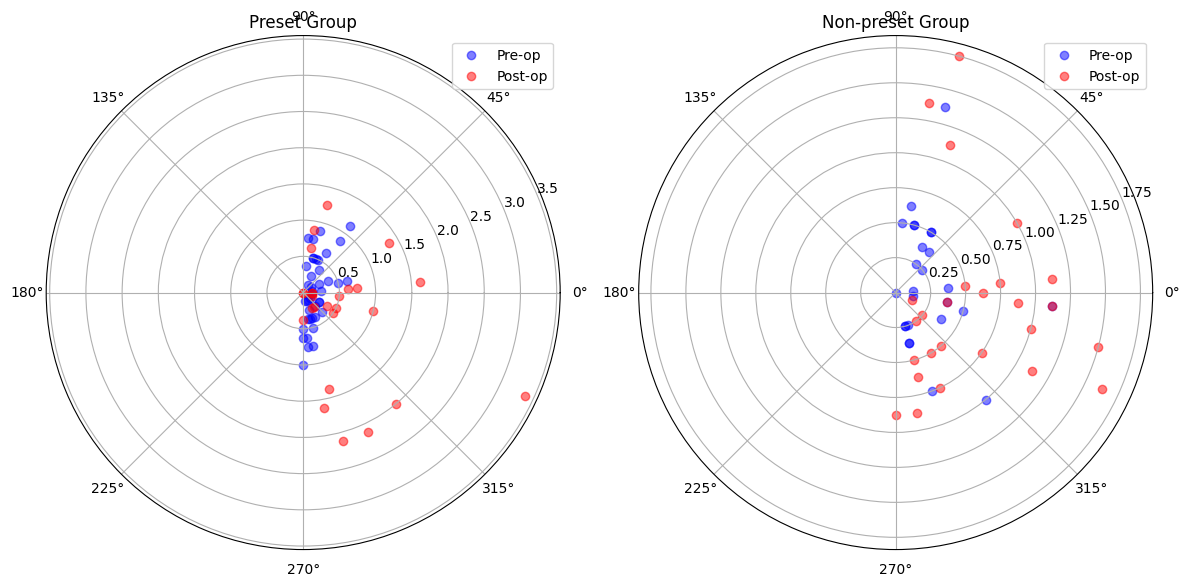

In [120]:
import matplotlib.pyplot as plt

# Convert data
r_pre_p, theta_pre_p = to_polar(preop_preset)
r_post_p, theta_post_p = to_polar(postop_preset)

r_pre_np, theta_pre_np = to_polar(preop_nonpreset)
r_post_np, theta_post_np = to_polar(postop_nonpreset)

# Create subplots
fig = plt.figure(figsize=(12,6))

# ---------------- PRESET ----------------
ax1 = plt.subplot(1,2,1, projection='polar')

ax1.scatter(theta_pre_p, r_pre_p, alpha=0.5, label='Pre-op', color='blue')
ax1.scatter(theta_post_p, r_post_p, alpha=0.5, label='Post-op', color='red')

ax1.set_title("Preset Group")
ax1.legend(loc='upper right')

# ---------------- NON-PRESET ----------------
ax2 = plt.subplot(1,2,2, projection='polar')

ax2.scatter(theta_pre_np, r_pre_np, alpha=0.5, label='Pre-op', color='blue')
ax2.scatter(theta_post_np, r_post_np, alpha=0.5, label='Post-op', color='red')

ax2.set_title("Non-preset Group")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

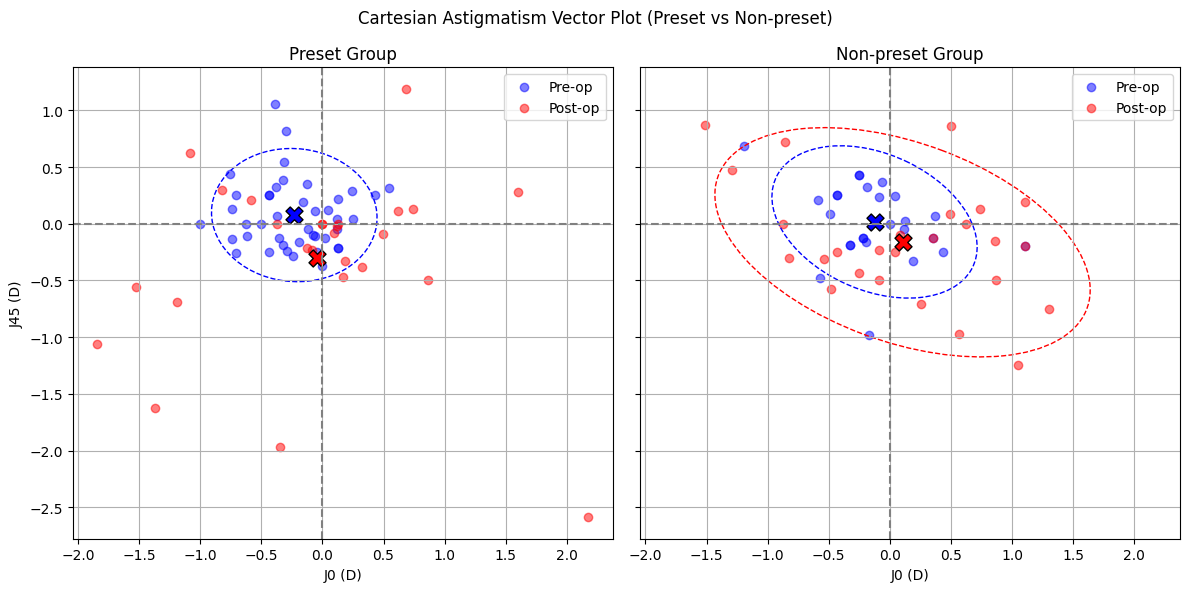

In [121]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def plot_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    if len(x) < 2 or len(y) < 2:
        return # Not enough data to compute covariance

    cov = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort eigenvalues and eigenvectors
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    vx, vy = eigenvectors[:,0][0], eigenvectors[:,0][1]
    theta = np.arctan2(vy, vx)

    width, height = 2 * n_std * np.sqrt(eigenvalues)

    # Handle cases where covariance matrix might lead to non-positive eigenvalues or very small values
    if width <= 0 or height <= 0:
        return

    ellipse = Ellipse(xy=(np.mean(x), np.mean(y)), width=width, height=height,
                      angle=np.degrees(theta), facecolor=facecolor, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# ---------------- PRESET ----------------
ax = axes[0]

ax.scatter(preop_preset['J0'], preop_preset['J45'],
           color='blue', alpha=0.5, label='Pre-op')

ax.scatter(postop_preset['J0'], postop_preset['J45'],
           color='red', alpha=0.5, label='Post-op')

# Centroids
ax.scatter(preop_preset['J0'].mean(), preop_preset['J45'].mean(),
           color='blue', marker='X', s=150, edgecolor='black')

ax.scatter(postop_preset['J0'].mean(), postop_preset['J45'].mean(),
           color='red', marker='X', s=150, edgecolor='black')

ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

ax.set_title("Preset Group")
ax.set_xlabel("J0 (D)")
ax.set_ylabel("J45 (D)")
ax.grid(True)
ax.legend()

plot_confidence_ellipse(preop_preset['J0'], preop_preset['J45'],
                        ax, edgecolor='blue', linestyle='--', n_std=1.96, label='Pre-op 95% CI')

plot_confidence_ellipse(postop_preset['J0'], postop_preset['J45'],
                        ax, edgecolor='red', linestyle='--', n_std=1.96, label='Post-op 95% CI')

# ---------------- NON-PRESET ----------------
ax = axes[1]

ax.scatter(preop_nonpreset['J0'], preop_nonpreset['J45'],
           color='blue', alpha=0.5, label='Pre-op')

ax.scatter(postop_nonpreset['J0'], postop_nonpreset['J45'],
           color='red', alpha=0.5, label='Post-op')

# Centroids
ax.scatter(preop_nonpreset['J0'].mean(), preop_nonpreset['J45'].mean(),
           color='blue', marker='X', s=150, edgecolor='black')

ax.scatter(postop_nonpreset['J0'].mean(), postop_nonpreset['J45'].mean(),
           color='red', marker='X', s=150, edgecolor='black')

ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

ax.set_title("Non-preset Group")
ax.set_xlabel("J0 (D)")
ax.grid(True)
ax.legend()

plot_confidence_ellipse(preop_nonpreset['J0'], preop_nonpreset['J45'],
                        ax, edgecolor='blue', linestyle='--', n_std=1.96, label='Pre-op 95% CI')

plot_confidence_ellipse(postop_nonpreset['J0'], postop_nonpreset['J45'],
                        ax, edgecolor='red', linestyle='--', n_std=1.96, label='Post-op 95% CI')

plt.suptitle("Cartesian Astigmatism Vector Plot (Preset vs Non-preset)")
plt.tight_layout()
plt.show()

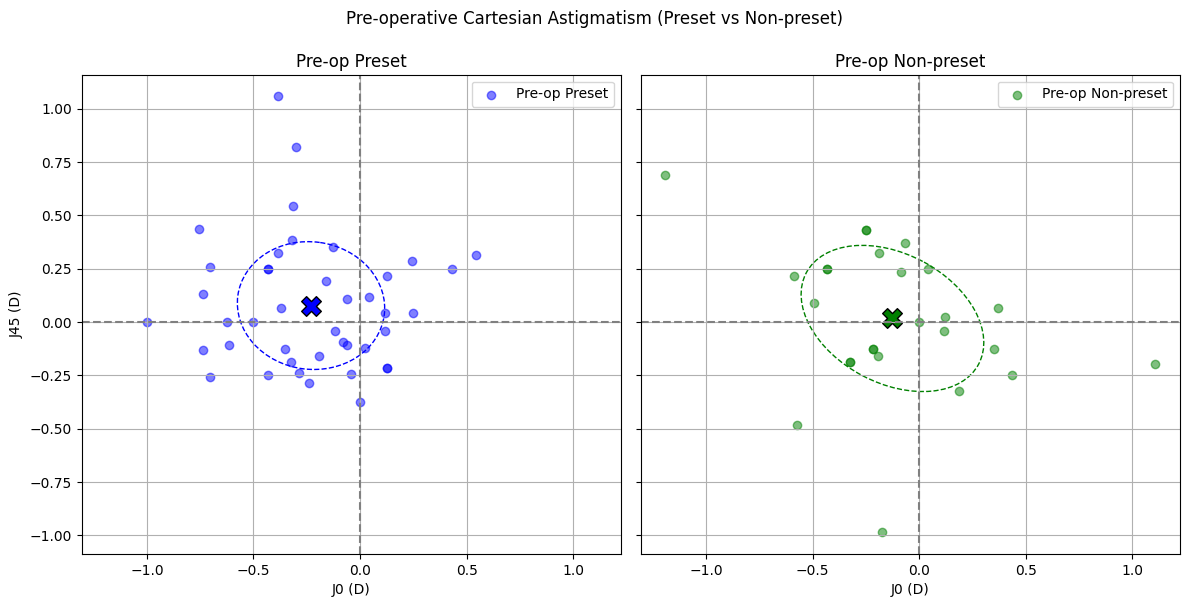

In [122]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# ---------------- PRESET (PRE-OP ONLY) ----------------
ax = axes[0]

ax.scatter(preop_preset['J0'], preop_preset['J45'],
           color='blue', alpha=0.5, label='Pre-op Preset')

# Centroid
ax.scatter(preop_preset['J0'].mean(), preop_preset['J45'].mean(),
           color='blue', marker='X', s=200, edgecolor='black')

# Confidence ellipse
plot_confidence_ellipse(preop_preset['J0'], preop_preset['J45'],
                        ax, edgecolor='blue', linestyle='--')

ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

ax.set_title("Pre-op Preset")
ax.set_xlabel("J0 (D)")
ax.set_ylabel("J45 (D)")
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()


# ---------------- NON-PRESET (PRE-OP ONLY) ----------------
ax = axes[1]

ax.scatter(preop_nonpreset['J0'], preop_nonpreset['J45'],
           color='green', alpha=0.5, label='Pre-op Non-preset')

# Centroid
ax.scatter(preop_nonpreset['J0'].mean(), preop_nonpreset['J45'].mean(),
           color='green', marker='X', s=200, edgecolor='black')

# Confidence ellipse
plot_confidence_ellipse(preop_nonpreset['J0'], preop_nonpreset['J45'],
                        ax, edgecolor='green', linestyle='--')

ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

ax.set_title("Pre-op Non-preset")
ax.set_xlabel("J0 (D)")
ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()


plt.suptitle("Pre-operative Cartesian Astigmatism (Preset vs Non-preset)")
plt.tight_layout()
plt.show()

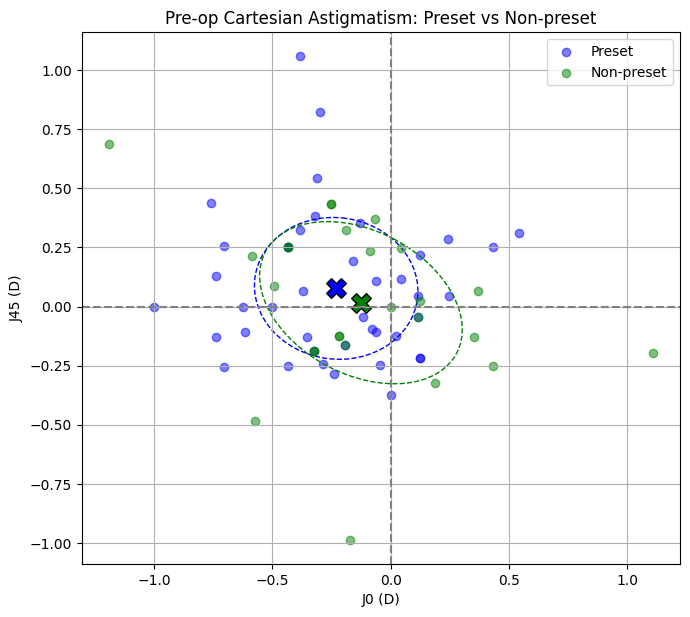

In [123]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

# -------- PRESET --------
ax.scatter(preop_preset['J0'], preop_preset['J45'],
           color='blue', alpha=0.5, label='Preset')

# Centroid
ax.scatter(preop_preset['J0'].mean(), preop_preset['J45'].mean(),
           color='blue', marker='X', s=200, edgecolor='black')

# Ellipse
plot_confidence_ellipse(preop_preset['J0'], preop_preset['J45'],
                        ax, edgecolor='blue', linestyle='--')


# -------- NON-PRESET --------
ax.scatter(preop_nonpreset['J0'], preop_nonpreset['J45'],
           color='green', alpha=0.5, label='Non-preset')

# Centroid
ax.scatter(preop_nonpreset['J0'].mean(), preop_nonpreset['J45'].mean(),
           color='green', marker='X', s=200, edgecolor='black')

# Ellipse
plot_confidence_ellipse(preop_nonpreset['J0'], preop_nonpreset['J45'],
                        ax, edgecolor='green', linestyle='--')


# -------- AXES --------
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

ax.set_xlabel("J0 (D)")
ax.set_ylabel("J45 (D)")
ax.set_title("Pre-op Cartesian Astigmatism: Preset vs Non-preset")

ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

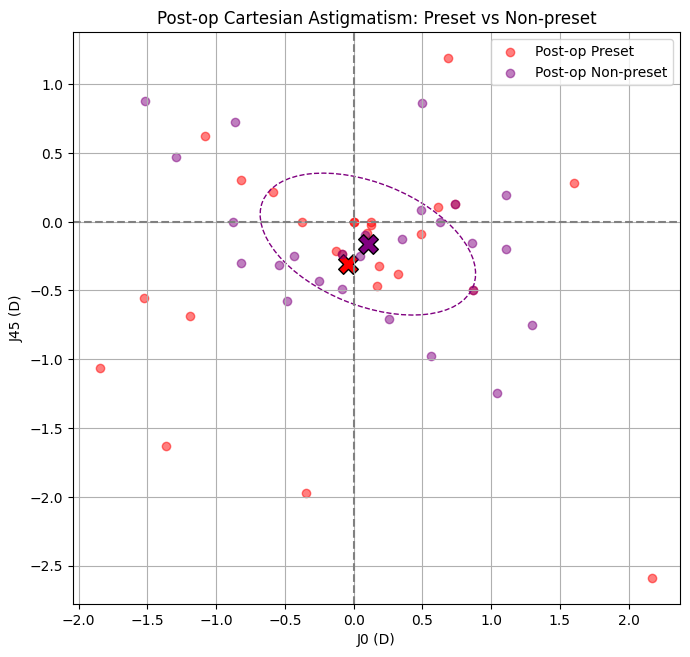

In [124]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

# -------- PRESET (POST-OP) --------
ax.scatter(postop_preset['J0'], postop_preset['J45'],
           color='red', alpha=0.5, label='Post-op Preset')

# Centroid
ax.scatter(postop_preset['J0'].mean(), postop_preset['J45'].mean(),
           color='red', marker='X', s=200, edgecolor='black')

# Ellipse
plot_confidence_ellipse(postop_preset['J0'], postop_preset['J45'],
                        ax, edgecolor='red', linestyle='--')


# -------- NON-PRESET (POST-OP) --------
ax.scatter(postop_nonpreset['J0'], postop_nonpreset['J45'],
           color='purple', alpha=0.5, label='Post-op Non-preset')

# Centroid
ax.scatter(postop_nonpreset['J0'].mean(), postop_nonpreset['J45'].mean(),
           color='purple', marker='X', s=200, edgecolor='black')

# Ellipse
plot_confidence_ellipse(postop_nonpreset['J0'], postop_nonpreset['J45'],
                        ax, edgecolor='purple', linestyle='--')


# -------- AXES --------
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

ax.set_xlabel("J0 (D)")
ax.set_ylabel("J45 (D)")
ax.set_title("Post-op Cartesian Astigmatism: Preset vs Non-preset")

ax.set_aspect('equal', adjustable='box')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

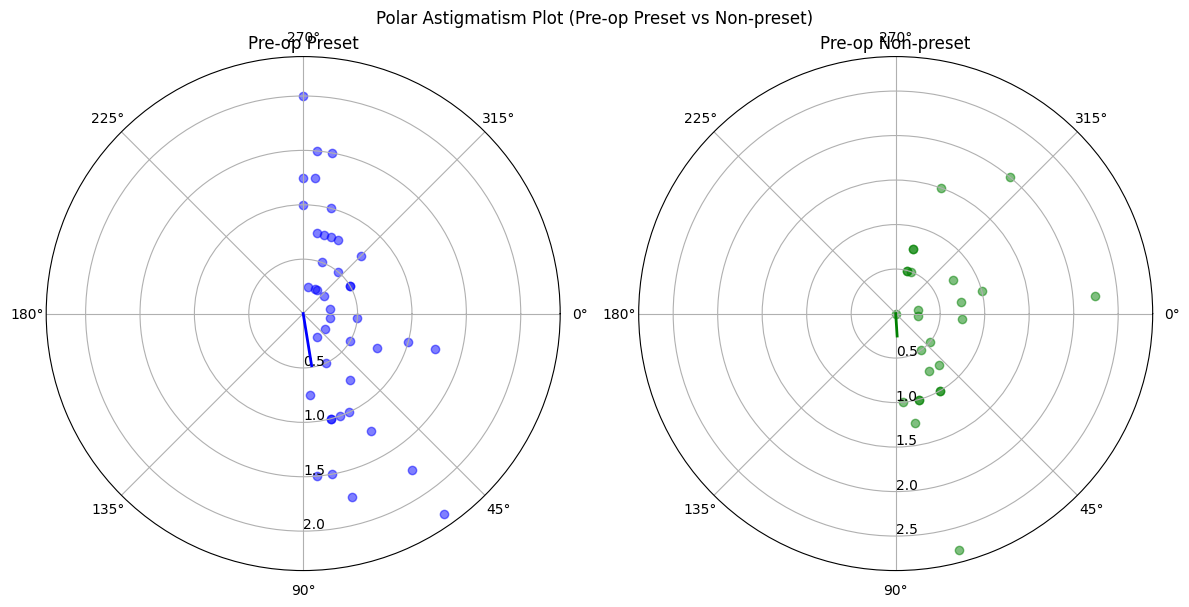

In [125]:
import numpy as np
import matplotlib.pyplot as plt

def to_polar(J0, J45):
    magnitude = 2 * np.sqrt(J0**2 + J45**2)
    angle = 0.5 * np.arctan2(J45, J0)  # radians
    return magnitude, angle

fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                         subplot_kw={'projection': 'polar'})

# -------- PRESET --------
ax = axes[0]

mag, ang = to_polar(preop_preset['J0'], preop_preset['J45'])

ax.scatter(ang, mag, color='blue', alpha=0.5)

# Mean vector
mean_J0 = preop_preset['J0'].mean()
mean_J45 = preop_preset['J45'].mean()
mean_mag, mean_ang = to_polar(mean_J0, mean_J45)

ax.plot([mean_ang, mean_ang], [0, mean_mag],
        color='blue', linewidth=2)

ax.set_title("Pre-op Preset")


# -------- NON-PRESET --------
ax = axes[1]

mag, ang = to_polar(preop_nonpreset['J0'], preop_nonpreset['J45'])

ax.scatter(ang, mag, color='green', alpha=0.5)

# Mean vector
mean_J0 = preop_nonpreset['J0'].mean()
mean_J45 = preop_nonpreset['J45'].mean()
mean_mag, mean_ang = to_polar(mean_J0, mean_J45)

ax.plot([mean_ang, mean_ang], [0, mean_mag],
        color='green', linewidth=2)

ax.set_title("Pre-op Non-preset")


# -------- Formatting --------
for ax in axes:
    ax.set_theta_zero_location("E")   # 0° at horizontal (like J0 axis)
    ax.set_theta_direction(-1)        # clockwise (ophthalmic convention)
    ax.set_rlabel_position(90)
    ax.grid(True)

plt.suptitle("Polar Astigmatism Plot (Pre-op Preset vs Non-preset)")
plt.tight_layout()
plt.show()

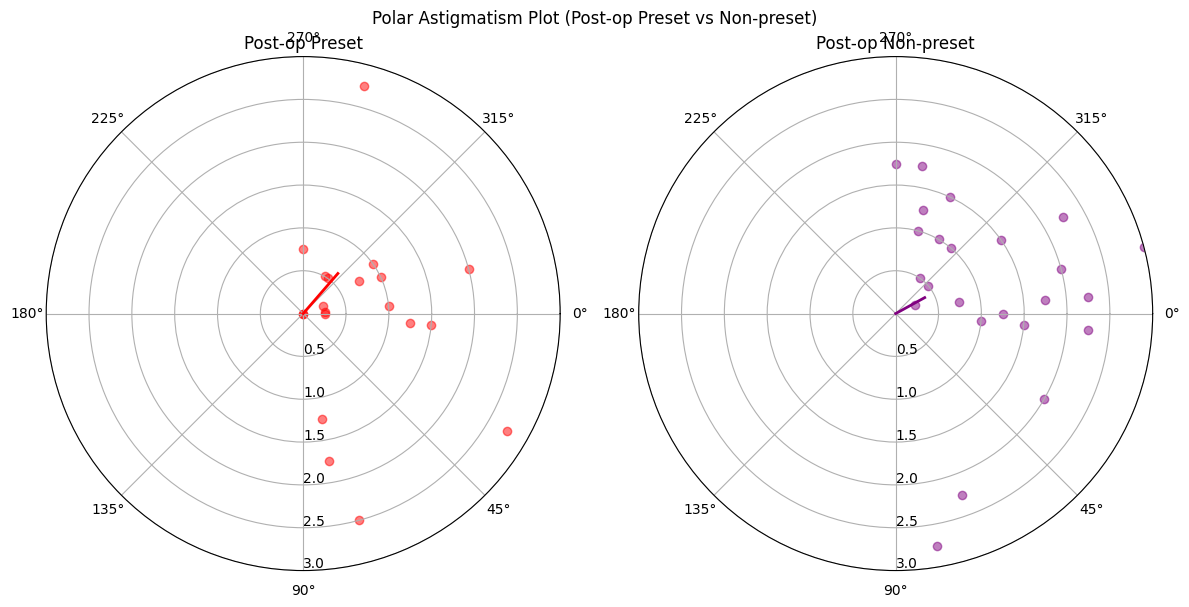

In [126]:
import numpy as np
import matplotlib.pyplot as plt

def to_polar(J0, J45):
    magnitude = 2 * np.sqrt(J0**2 + J45**2)
    angle = 0.5 * np.arctan2(J45, J0)  # radians
    return magnitude, angle

fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                         subplot_kw={'projection': 'polar'})

# -------- POST-OP PRESET --------
ax = axes[0]

mag, ang = to_polar(postop_preset['J0'], postop_preset['J45'])
ax.scatter(ang, mag, color='red', alpha=0.5)

# Mean vector
mean_J0 = postop_preset['J0'].mean()
mean_J45 = postop_preset['J45'].mean()
mean_mag, mean_ang = to_polar(mean_J0, mean_J45)

ax.plot([mean_ang, mean_ang], [0, mean_mag],
        color='red', linewidth=2)

ax.set_title("Post-op Preset")


# -------- POST-OP NON-PRESET --------
ax = axes[1]

mag, ang = to_polar(postop_nonpreset['J0'], postop_nonpreset['J45'])
ax.scatter(ang, mag, color='purple', alpha=0.5)

# Mean vector
mean_J0 = postop_nonpreset['J0'].mean()
mean_J45 = postop_nonpreset['J45'].mean()
mean_mag, mean_ang = to_polar(mean_J0, mean_J45)

ax.plot([mean_ang, mean_ang], [0, mean_mag],
        color='purple', linewidth=2)

ax.set_title("Post-op Non-preset")


# -------- Formatting --------
for ax in axes:
    ax.set_theta_zero_location("E")   # 0° aligned with J0 axis
    ax.set_theta_direction(-1)        # clockwise (clinical convention)
    ax.set_rlabel_position(90)
    ax.set_rlim(0, 3)  # keep consistent with pre-op if possible
    ax.grid(True)

plt.suptitle("Polar Astigmatism Plot (Post-op Preset vs Non-preset)")
plt.tight_layout()
plt.show()